<a href="https://colab.research.google.com/github/Youngstg/EDA-Breast-Cancer/blob/main/EDA_Breast_Cancer_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis: Diagnosis Kanker Payudara
### Breast Cancer Wisconsin (Diagnostic) Dataset

**Author:** Lucky Immanuel Sitanggang &nbsp;|&nbsp; **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, scikit-learn

---

## Latar Belakang
Kanker payudara merupakan salah satu jenis kanker paling umum di dunia, dan deteksi dini sangat menentukan peluang kesembuhan pasien. Salah satu pendekatan diagnosis adalah *Fine Needle Aspiration* (FNA), yaitu pengambilan sampel sel dari massa payudara yang kemudian dianalisis melalui citra digital. Dari citra tersebut diekstraksi karakteristik inti sel, seperti ukuran, tekstur, dan bentuk, untuk membedakan tumor **jinak (benign)** dan **ganas (malignant)**.

## Tujuan Analisis
Proyek ini merupakan tahap *Exploratory Data Analysis* (EDA) sebagai fondasi sebelum *preprocessing* dan *modeling*. Pertanyaan yang ingin dijawab:
1. Bagaimana kualitas dan struktur data yang tersedia?
2. Karakteristik sel apa yang paling membedakan tumor jinak dan ganas?
3. Apakah perbedaan tersebut signifikan secara statistik?
4. Tantangan apa yang perlu diantisipasi pada tahap modeling (ketidakseimbangan kelas, multikolinearitas, outlier)?

## Tentang Dataset
| Aspek | Keterangan |
|---|---|
| Sumber | UCI Machine Learning Repository (Wisconsin Diagnostic Breast Cancer), diakses melalui `sklearn.datasets.load_breast_cancer` |
| Jumlah sampel | 569 pasien |
| Jumlah fitur | 30 fitur numerik kontinu |
| Target | `malignant` (ganas) dan `benign` (jinak) |
| Struktur fitur | 10 karakteristik inti sel × 3 ukuran statistik: **mean**, **standard error**, dan **worst** (rata-rata dari tiga nilai terbesar) |

Sepuluh karakteristik inti sel yang diukur: *radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry,* dan *fractal dimension*.

## Alur Analisis
1. Pemuatan Data
2. Pemeriksaan Kualitas Data
3. Statistik Deskriptif, Skewness & Kurtosis
4. Distribusi Kelas Target
5. Distribusi Fitur per Kelas (Histogram & ECDF)
6. Perbandingan Antar Kelas (Boxplot, Violin, Strip Plot)
7. Uji Signifikansi Statistik (Mann-Whitney U)
8. Korelasi & Multikolinearitas (Heatmap, Clustermap, VIF)
9. Hubungan Multivariat (Pairplot & Jointplot)
10. Deteksi Outlier (Metode IQR)
11. Reduksi Dimensi (PCA & t-SNE)
12. Estimasi Awal Feature Importance
13. Kesimpulan & Rencana Tahap Berikutnya


In [ ]:
# =========================================
# 1. IMPORT LIBRARY
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

print("Library berhasil di-import ✅")


Library berhasil di-import ✅


## 1. Pemuatan Data
Data dimuat ke dalam *DataFrame*, kemudian kolom target diberi label yang mudah dibaca. Fitur juga dikelompokkan ke dalam tiga kategori (`mean`, `error`, `worst`) untuk mempermudah analisis per kelompok.

In [ ]:
# =========================================
# LOAD DATA
# =========================================
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

mean_cols = [c for c in df.columns if c.startswith("mean")]
error_cols = [c for c in df.columns if "error" in c]
worst_cols = [c for c in df.columns if c.startswith("worst")]

print(f"Jumlah baris (sampel) : {df.shape[0]}")
print(f"Jumlah fitur          : {len(data.feature_names)}  -> mean:{len(mean_cols)}, error:{len(error_cols)}, worst:{len(worst_cols)}")
df.head()


Jumlah baris (sampel) : 569
Jumlah fitur          : 30  -> mean:10, error:10, worst:10


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 2. Pemeriksaan Kualitas Data
Sebelum analisis lebih lanjut, dilakukan validasi struktur data: tipe data, nilai kosong, dan baris duplikat. Tahap ini memastikan kesimpulan yang diambil kemudian tidak bias oleh masalah kualitas data.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print(f"Total missing value       : {missing.sum()}")
print(f"Jumlah baris duplikat     : {duplicates}")
print(f"Rentang nilai target      : {sorted(df['target'].unique())}")


Total missing value       : 0
Jumlah baris duplikat     : 0
Rentang nilai target      : [np.int64(0), np.int64(1)]


### Analisis kualitas data

Dari output `df.info()`, seluruh **569 baris** memiliki nilai pada **30 fitur numerik**. Tidak ada nilai kosong maupun baris yang identik, sehingga tidak diperlukan imputasi atau penghapusan duplikat sebelum eksplorasi. Kolom `target` (`0 = malignant`, `1 = benign`) dan `diagnosis` merupakan dua bentuk label yang sama; keduanya harus dikeluarkan dari kumpulan fitur prediktor. Pemeriksaan ini menilai kebersihan data secara struktural, tetapi belum memverifikasi identitas pasien atau ketepatan tiap pengukuran.

## 3. Statistik Deskriptif, Skewness & Kurtosis
Statistik deskriptif memberikan gambaran awal skala dan sebaran tiap fitur. Selain itu, **skewness** dan **kurtosis** dihitung untuk menilai seberapa jauh distribusi menyimpang dari distribusi normal. Informasi ini menjadi dasar keputusan transformasi (misalnya log-transform) pada tahap *preprocessing*.

In [ ]:
df[data.feature_names].describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


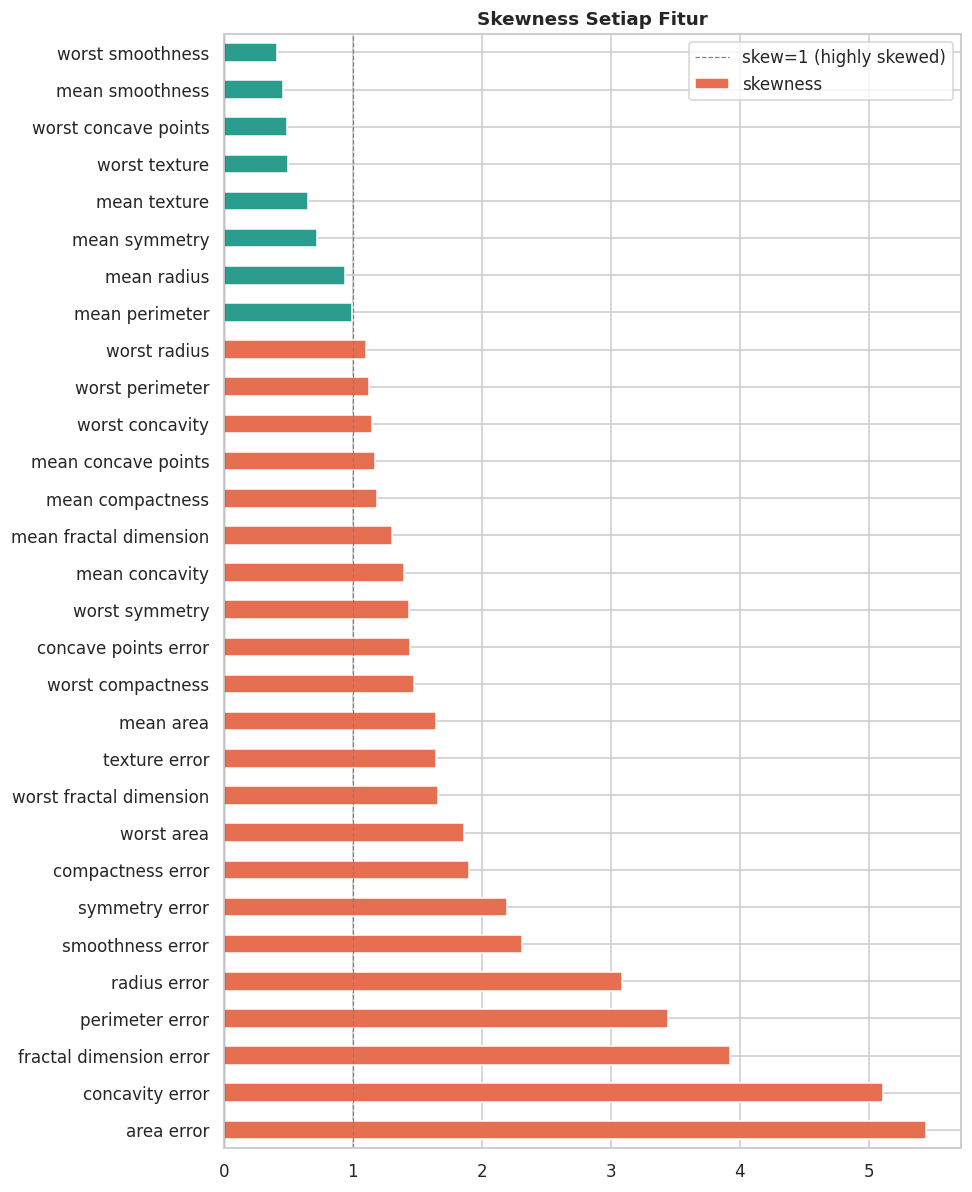

,skewness,kurtosis
area error,5.447186,49.209077
concavity error,5.110463,48.861395
fractal dimension error,3.923969,26.280847
perimeter error,3.443615,21.401905
radius error,3.088612,17.686726
smoothness error,2.314450,10.469840
symmetry error,2.195133,7.896130
compactness error,1.902221,5.106252


In [ ]:
# =========================================
# VISUALISASI: Skewness & Kurtosis tiap fitur
# =========================================
skew_kurt = pd.DataFrame({
    "skewness": df[data.feature_names].skew(),
    "kurtosis": df[data.feature_names].kurtosis()
}).sort_values("skewness", ascending=False)

fig, ax = plt.subplots(figsize=(9, 11))
skew_kurt["skewness"].plot.barh(ax=ax, color=np.where(skew_kurt["skewness"] > 1, "#e76f51", "#2a9d8f"))
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(1, color="grey", linestyle="--", linewidth=0.8, label="skew=1 (highly skewed)")
ax.set_title("Skewness Setiap Fitur", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

skew_kurt.head(8)


### Analisis statistik deskriptif dan skewness

**22 dari 30 fitur** mempunyai skewness > 1. Pada grafik, batang terpanjang adalah `area error` (**5,45**), `concavity error` (**5,11**), dan `fractal dimension error` (**3,92**). Sebagian kecil nilai yang sangat tinggi membentuk ekor kanan; contohnya median `area error` **24,53** jauh di bawah reratanya **40,34**. Sebaran yang menceng juga membuat median dan rentang kuartil lebih informatif saat membandingkan pusat distribusi.

Skala fitur berbeda jauh: median `mean area` **551,1**, sedangkan median `mean concave points` **0,0335**. Standardisasi layak diuji untuk algoritma yang sensitif terhadap skala. Transformasi `log1p` dapat diuji untuk fitur nonnegatif yang sangat menceng, tetapi tidak otomatis meningkatkan performa dan harus dimasukkan ke pipeline pelatihan agar tidak terjadi kebocoran data.

## 4. Distribusi Kelas Target
Proporsi kelas target diperiksa untuk mengetahui apakah data seimbang. Hal ini menentukan pemilihan metrik evaluasi dan strategi *train-test split* pada tahap modeling.

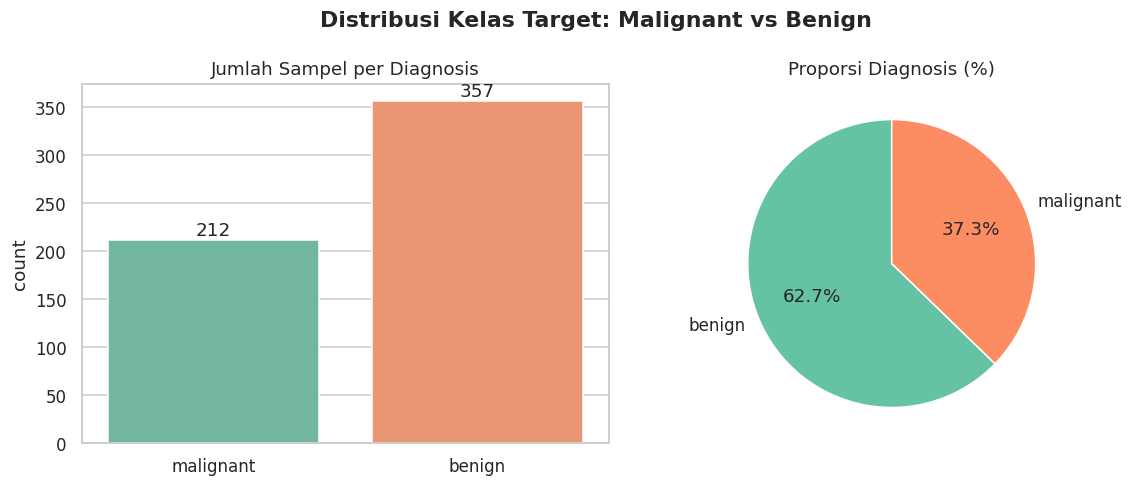

In [ ]:
# =========================================
# VISUALISASI: Distribusi Target
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.countplot(data=df, x="diagnosis", ax=axes[0], hue="diagnosis", legend=False)
axes[0].set_title("Jumlah Sampel per Diagnosis")
axes[0].set_xlabel("")
for container in axes[0].containers:
    axes[0].bar_label(container)

df["diagnosis"].value_counts().plot.pie(
    autopct="%1.1f%%", startangle=90, ax=axes[1],
    colors=sns.color_palette("Set2"), ylabel=""
)
axes[1].set_title("Proporsi Diagnosis (%)")

plt.suptitle("Distribusi Kelas Target: Malignant vs Benign", fontweight="bold")
plt.tight_layout()
plt.show()


### Analisis proporsi kelas

Grafik batang dan lingkaran menunjukkan **357 benign (62,7%)** dan **212 malignant (37,3%)**. Sebagai pembanding, aturan yang selalu menebak benign sudah meraih akurasi **62,7%** namun tidak mengenali satu pun kasus malignant. Karena itu, pada tahap modeling perlu *stratified split*, confusion matrix, dan recall untuk kelas malignant selain precision, F1, dan ROC-AUC. Rasio ini menunjukkan ketidakseimbangan moderat; kebutuhan resampling harus dibuktikan melalui validasi, bukan diasumsikan dari grafik saja.

## 5. Distribusi Fitur per Kelas
Distribusi fitur kelompok `mean` dan `worst` dibandingkan antara tumor jinak dan ganas menggunakan histogram (dengan estimasi KDE) serta **ECDF** (*Empirical Cumulative Distribution Function*). Semakin kecil area tumpang tindih antar kelas, semakin besar potensi fitur tersebut sebagai prediktor.

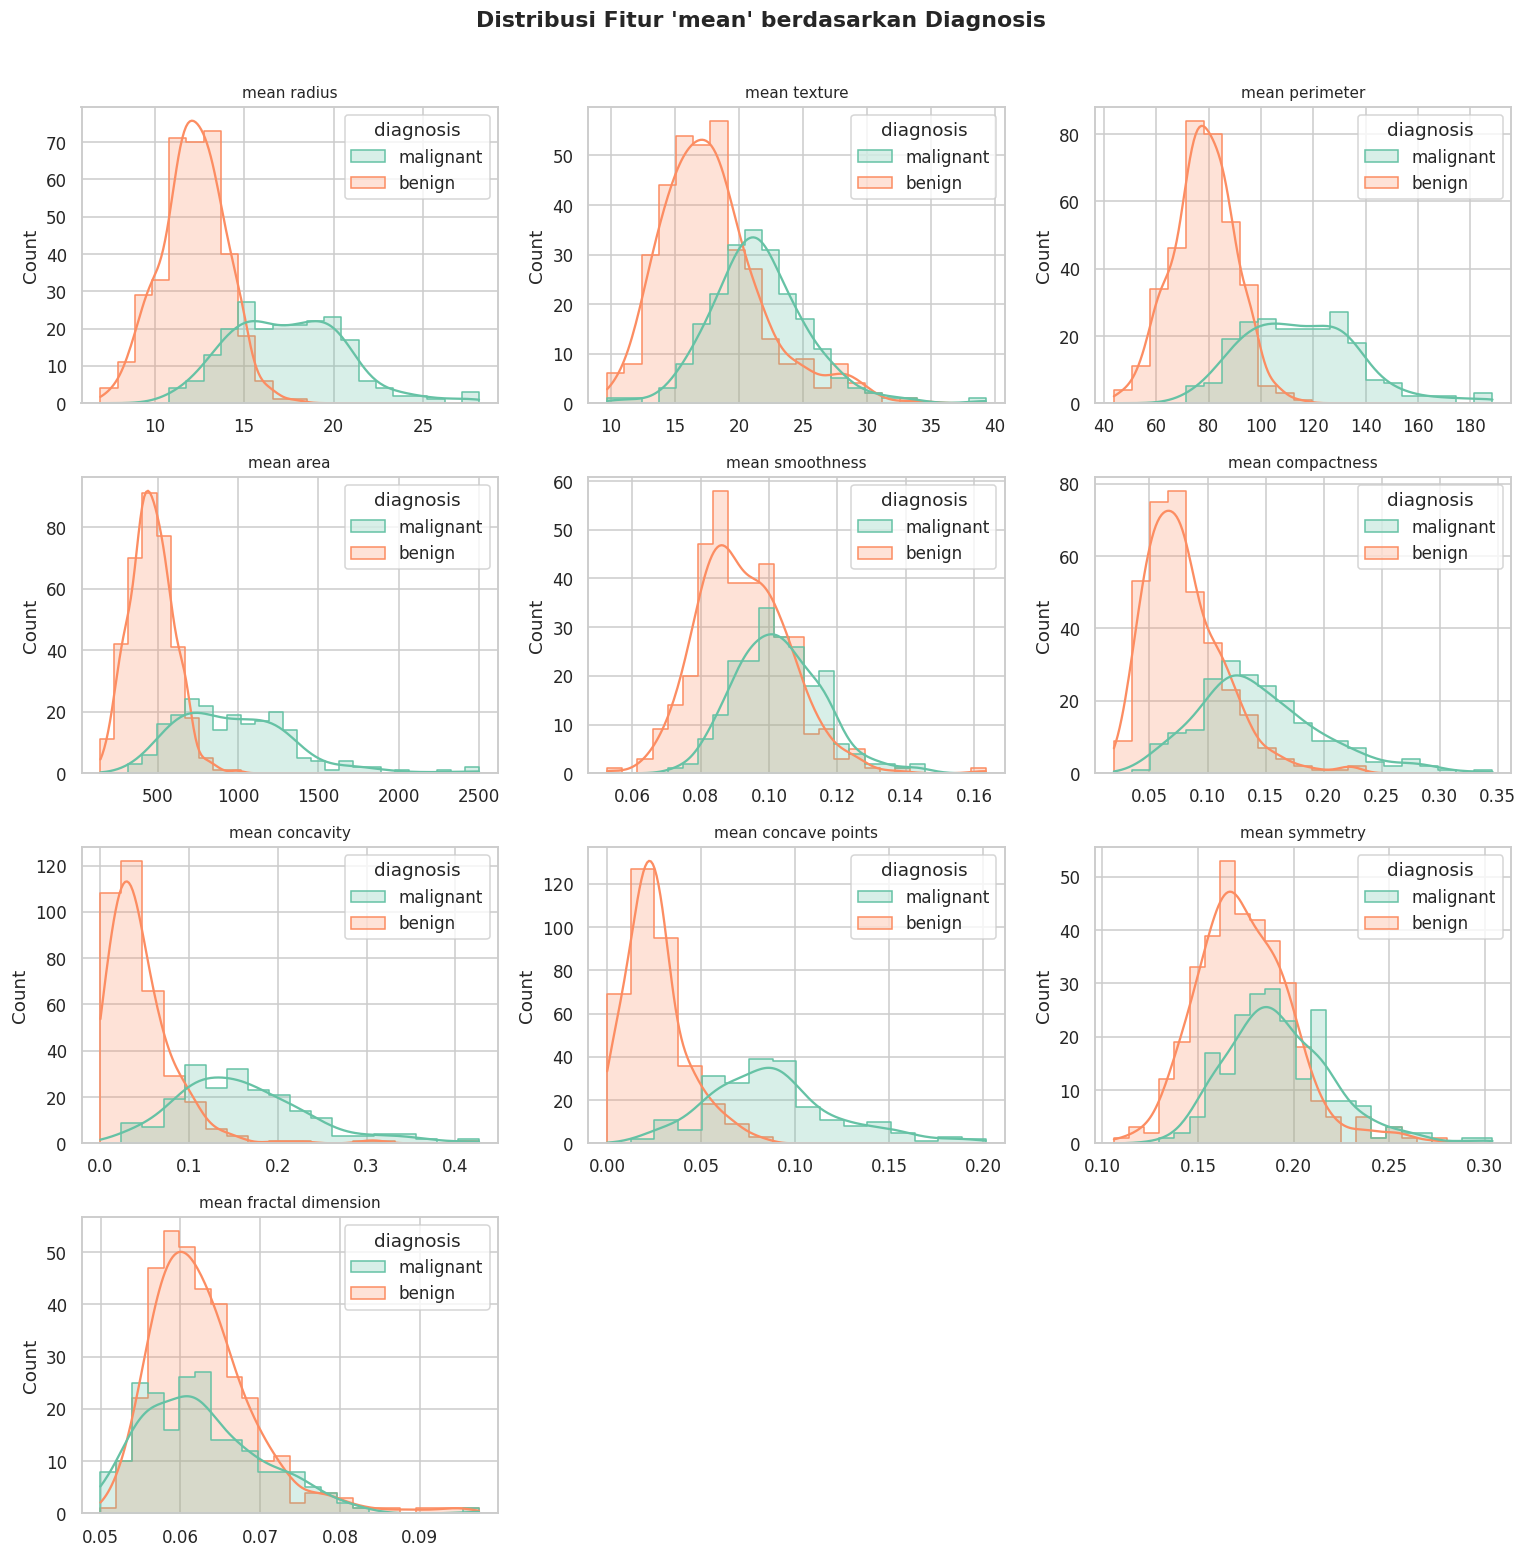

In [ ]:
# =========================================
# VISUALISASI: Histogram fitur 'mean'
# =========================================
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(mean_cols):
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True, ax=axes[i], element="step")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
for j in range(len(mean_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Distribusi Fitur 'mean' berdasarkan Diagnosis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


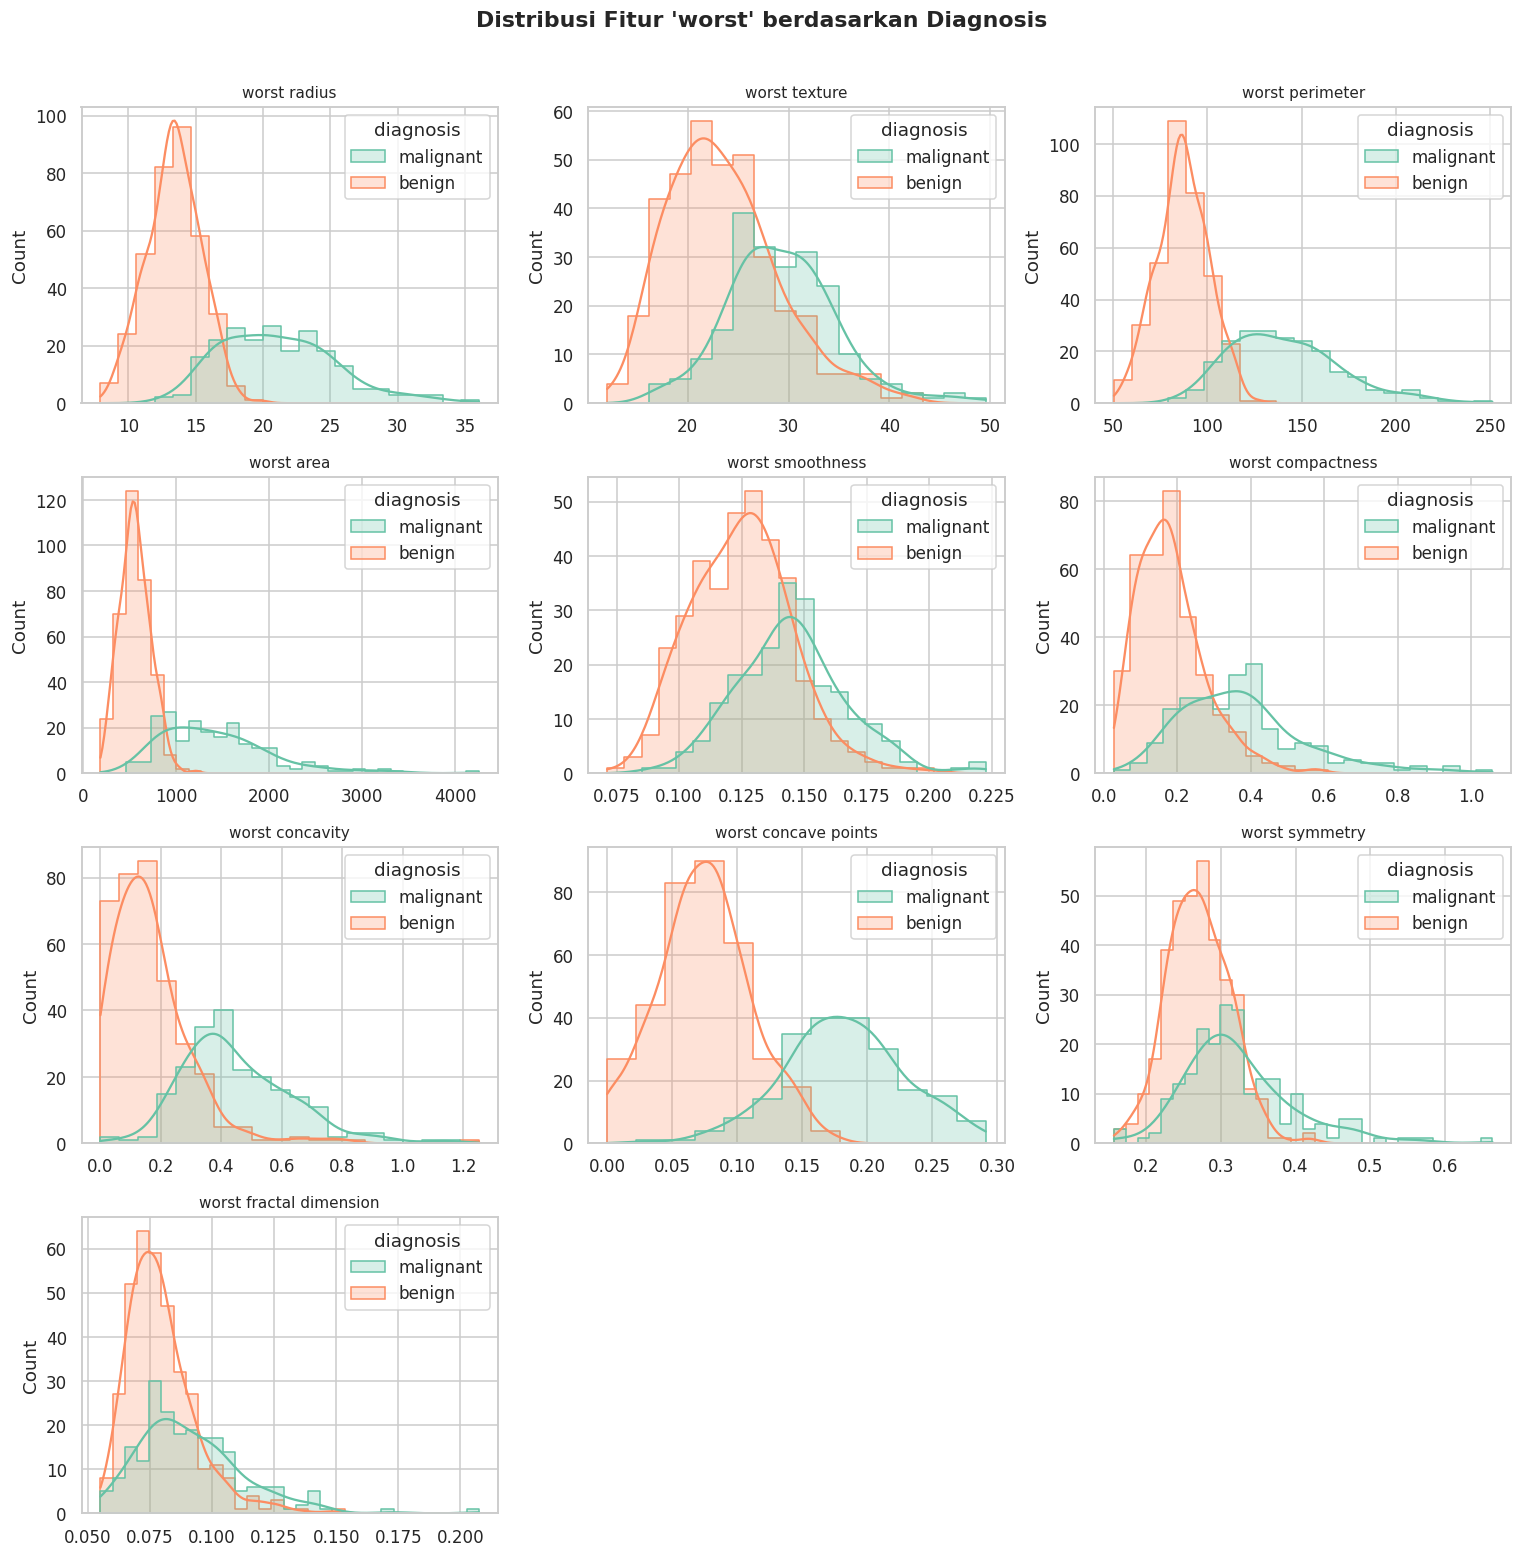

In [ ]:
# =========================================
# VISUALISASI: Histogram fitur 'worst'
# =========================================
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(worst_cols):
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True, ax=axes[i], element="step")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
for j in range(len(worst_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Distribusi Fitur 'worst' berdasarkan Diagnosis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


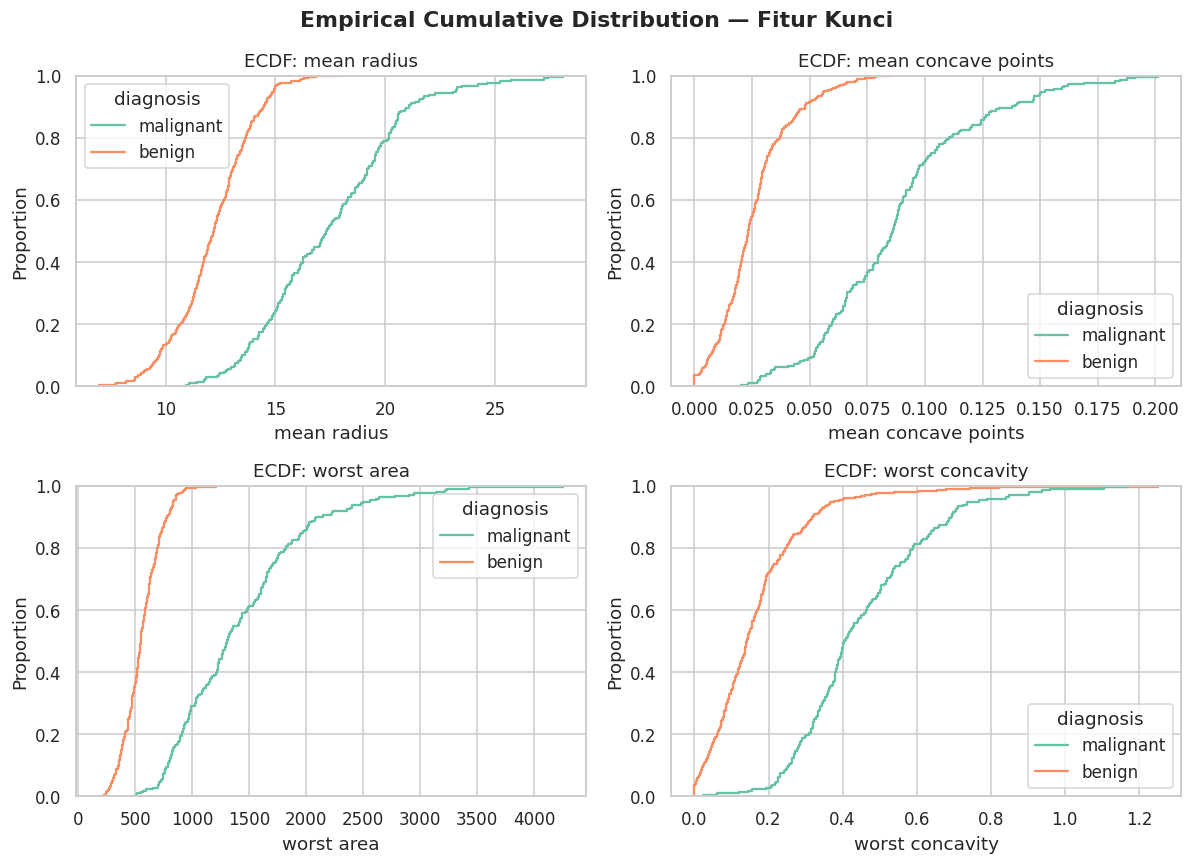

In [ ]:
# =========================================
# VISUALISASI: ECDF (Empirical CDF) untuk fitur-fitur kunci
# =========================================
key_features = ["mean radius", "mean concave points", "worst area", "worst concavity"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.ecdfplot(data=df, x=col, hue="diagnosis", ax=axes[i])
    axes[i].set_title(f"ECDF: {col}")
plt.suptitle("Empirical Cumulative Distribution — Fitur Kunci", fontweight="bold")
plt.tight_layout()
plt.show()


### Analisis histogram dan ECDF

Histogram kelompok `mean` dan `worst` memperlihatkan pergeseran nilai malignant ke kanan terutama pada ukuran (`radius`, `perimeter`, `area`) dan bentuk kontur (`concavity`, `concave points`). Median `mean radius` **17,325** pada malignant vs **12,200** pada benign; median `worst radius` **20,59** vs **13,35**. Pada `mean concave points`, median **0,0863** vs **0,0234**. Sebaliknya, `mean fractal dimension` dan beberapa ukuran tekstur memperlihatkan tumpang tindih yang lebih besar.

Empat panel ECDF menampilkan proporsi sampel yang nilainya tidak melebihi suatu titik. Untuk `mean radius`, `mean concave points`, `worst area`, dan `worst concavity`, kurva benign lebih cepat naik pada nilai rendah, sedangkan kurva malignant bergeser ke kanan. Kedua kelas tetap bertumpang tindih, sehingga **satu fitur saja tidak memberikan pemisahan sempurna**. Grafik ini menunjukkan asosiasi pada dataset, bukan aturan diagnosis individual.

## 6. Perbandingan Antar Kelas
Boxplot, violin plot, dan strip plot digunakan untuk membandingkan median, sebaran, kepadatan, serta posisi tiap sampel pada fitur-fitur utama. Kombinasi ketiganya memberi gambaran yang lebih lengkap dibanding satu jenis grafik saja.

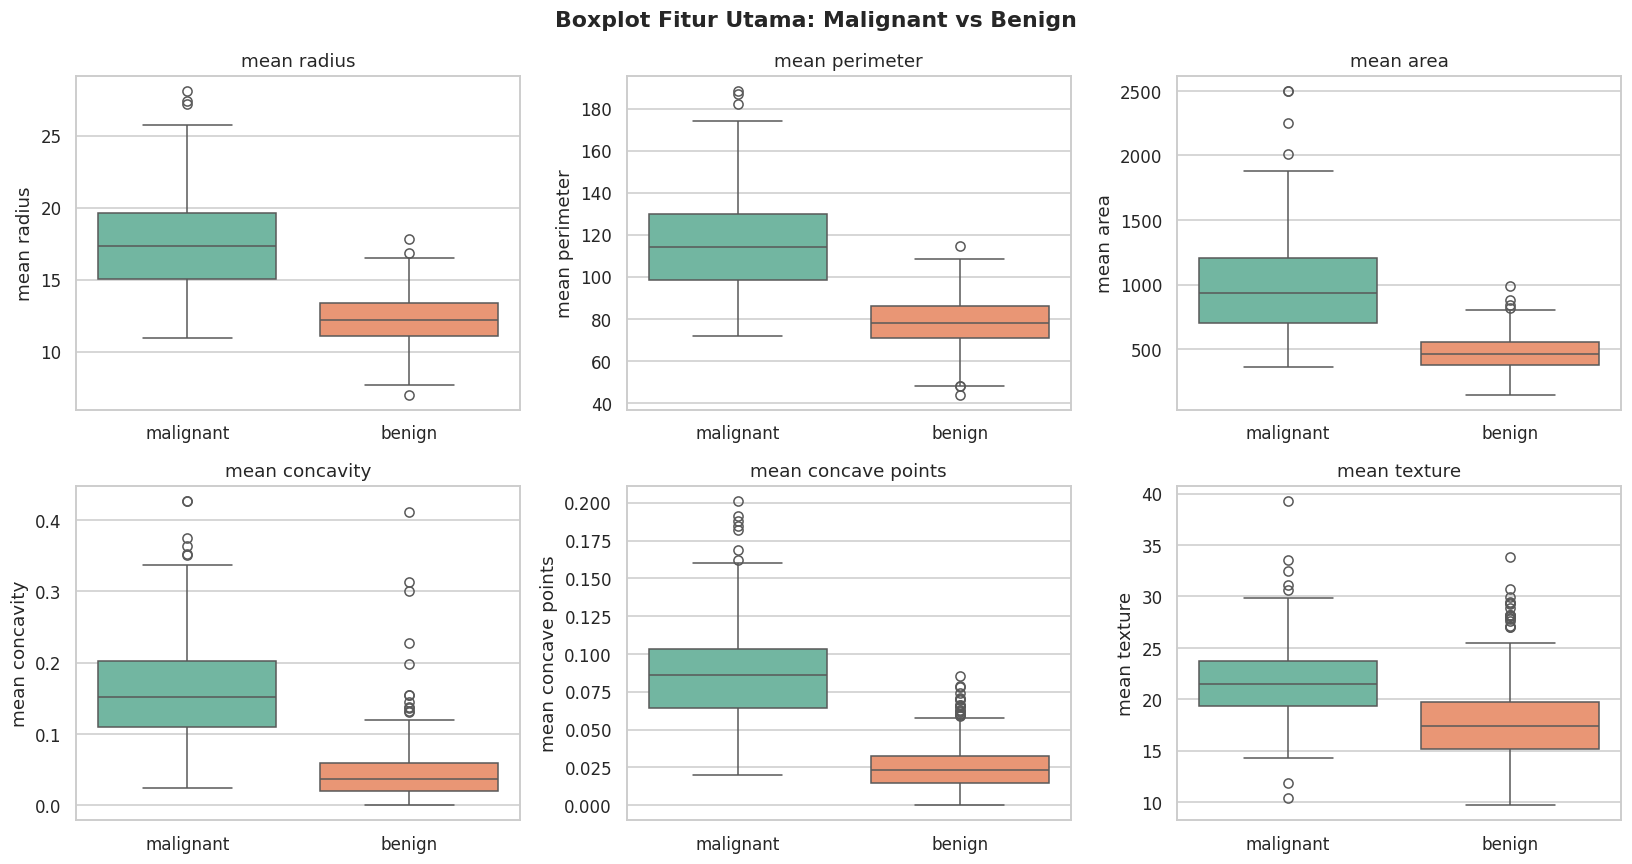

In [ ]:
top_features = ["mean radius", "mean perimeter", "mean area",
                 "mean concavity", "mean concave points", "mean texture"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(data=df, x="diagnosis", y=col, ax=axes[i], hue="diagnosis", legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
plt.suptitle("Boxplot Fitur Utama: Malignant vs Benign", fontweight="bold")
plt.tight_layout()
plt.show()


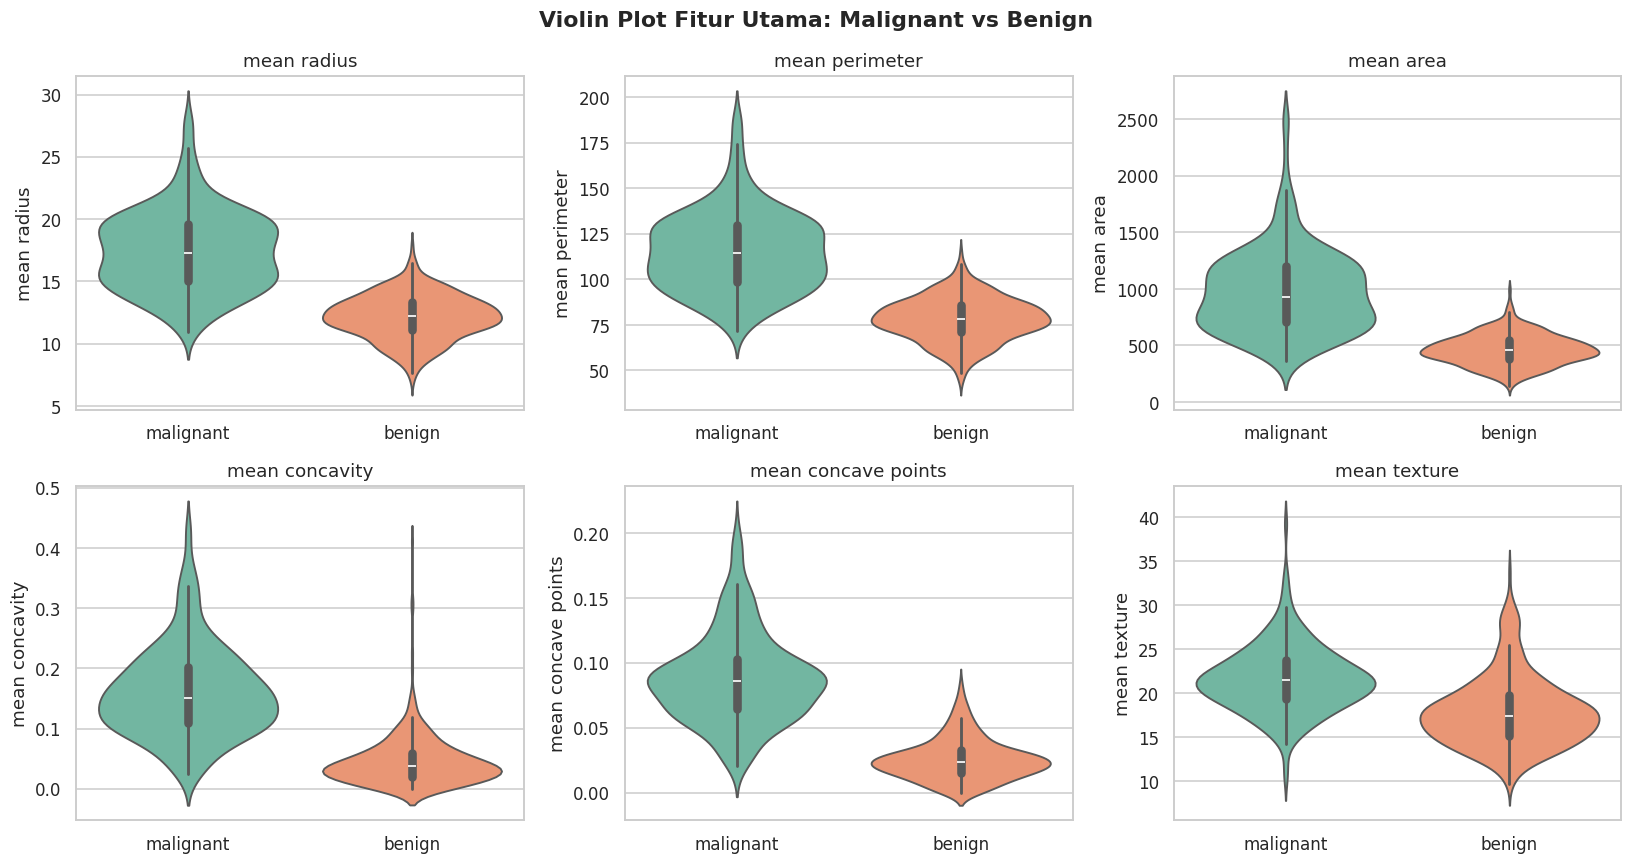

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.violinplot(data=df, x="diagnosis", y=col, ax=axes[i], hue="diagnosis", legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
plt.suptitle("Violin Plot Fitur Utama: Malignant vs Benign", fontweight="bold")
plt.tight_layout()
plt.show()


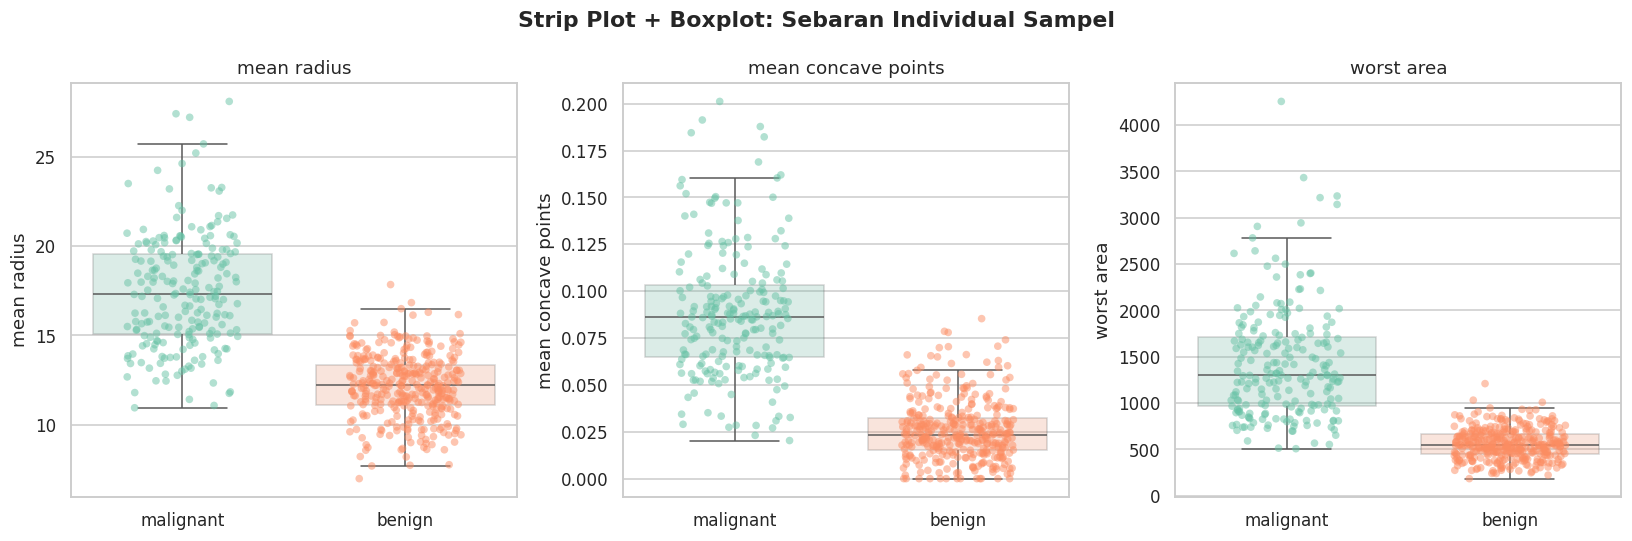

In [ ]:
# =========================================
# VISUALISASI: Swarm/Strip plot (sebaran titik individual)
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(["mean radius", "mean concave points", "worst area"]):
    sns.stripplot(data=df, x="diagnosis", y=col, ax=axes[i], hue="diagnosis",
                  legend=False, alpha=0.5, jitter=0.25)
    sns.boxplot(data=df, x="diagnosis", y=col, ax=axes[i], hue="diagnosis", legend=False,
                boxprops=dict(alpha=0.25), showfliers=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
plt.suptitle("Strip Plot + Boxplot: Sebaran Individual Sampel", fontweight="bold")
plt.tight_layout()
plt.show()


### Analisis boxplot, violin plot, dan strip plot

Pada enam boxplot, median kelas malignant cenderung lebih tinggi; perbedaannya tampak besar untuk `mean radius`, `mean perimeter`, `mean area`, dan `mean concave points`. Sebagai ukuran konkret, median `mean area` adalah **932,0** pada malignant dan **458,4** pada benign; median `worst area` pada strip plot **1.303,0** vs **547,4**. Violin plot memperlihatkan bentuk dan lebar distribusi, sementara titik individual menunjukkan bahwa sebagian sampel berada pada rentang yang sama. `mean texture` mempunyai pemisahan yang lebih lemah daripada ukuran dan kontur. Titik di luar kotak bukan otomatis kesalahan data; perbandingan visual ini juga belum mengukur akurasi klasifikasi.

## 7. Uji Signifikansi Statistik (Mann-Whitney U)
Perbedaan yang terlihat pada grafik perlu divalidasi secara statistik. Digunakan uji **Mann-Whitney U** (non-parametrik) karena banyak fitur tidak berdistribusi normal, sebagaimana ditunjukkan oleh skewness pada tahap sebelumnya.

- **H₀:** Distribusi fitur pada kelas malignant dan benign identik.
- **H₁:** Distribusi fitur kedua kelas berbeda.
- **Taraf signifikansi:** α = 0,05

In [ ]:
# =========================================
# UJI STATISTIK: Mann-Whitney U Test untuk semua fitur
# =========================================
results = []
for col in data.feature_names:
    g1 = df.loc[df["target"] == 0, col]
    g2 = df.loc[df["target"] == 1, col]
    stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    results.append({"feature": col, "p_value": p, "neg_log10_p": -np.log10(p + 1e-300)})

test_df = pd.DataFrame(results).sort_values("p_value")
print(f"Jumlah fitur dengan p-value < 0.05 : {(test_df['p_value'] < 0.05).sum()} dari {len(test_df)}")
test_df.head(10)


Jumlah fitur dengan p-value < 0.05 : 27 dari 30


,feature,p_value,neg_log10_p
22,worst perimeter,2.583004e-80,79.587875
20,worst radius,1.135630e-78,77.944763
23,worst area,1.803309e-78,77.743930
27,worst concave points,1.863997e-77,76.729555
7,mean concave points,1.006324e-76,75.997262
2,mean perimeter,3.553870e-71,70.449298
3,mean area,1.539780e-68,67.812541
6,mean concavity,2.164549e-68,67.664633
0,mean radius,2.692943e-68,67.569773
13,area error,5.767823e-65,64.238988


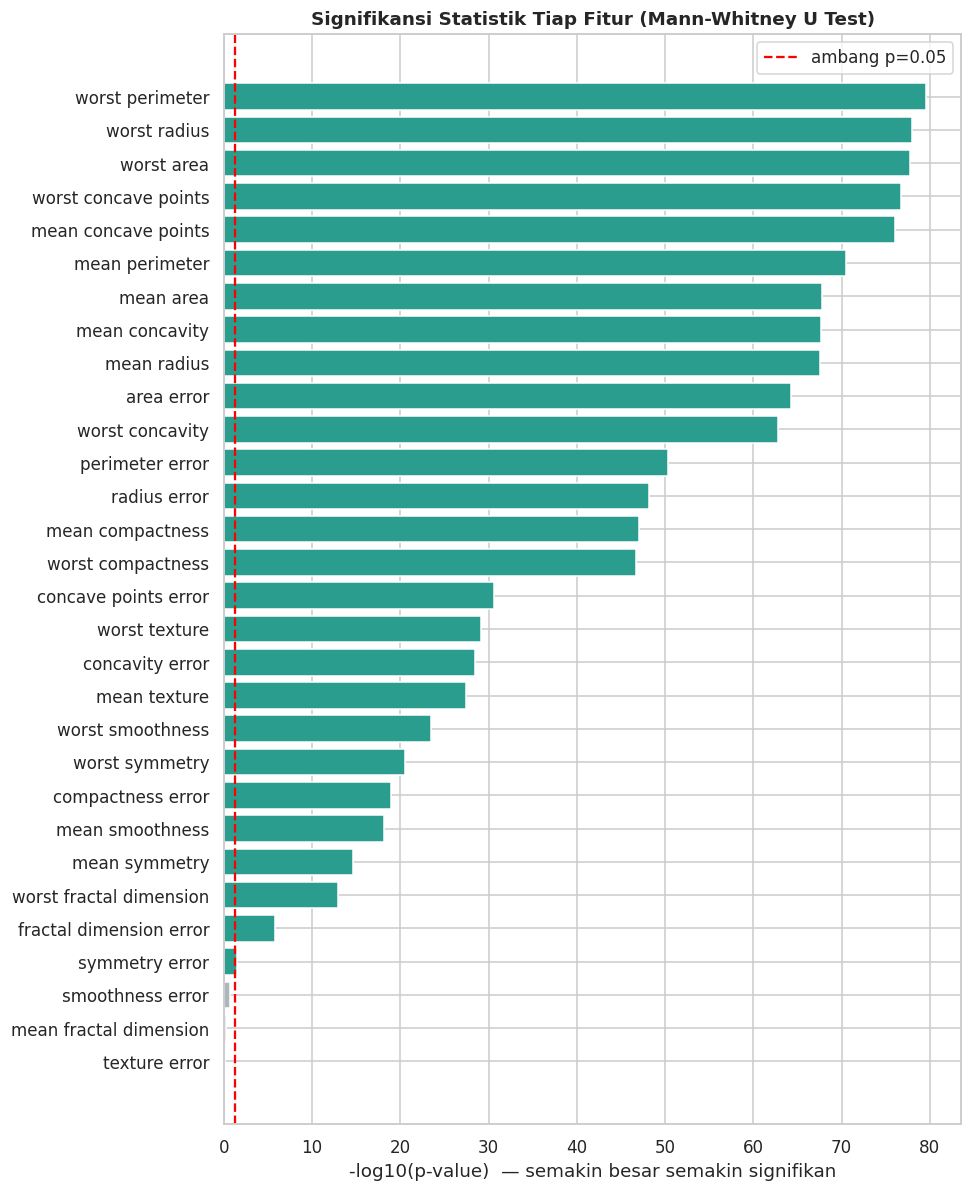

In [ ]:
# =========================================
# VISUALISASI: -log10(p-value) tiap fitur
# =========================================
plt.figure(figsize=(9, 11))
plot_df = test_df.sort_values("neg_log10_p")
colors = np.where(plot_df["p_value"] < 0.05, "#2a9d8f", "#adb5bd")
plt.barh(plot_df["feature"], plot_df["neg_log10_p"], color=colors)
plt.axvline(-np.log10(0.05), color="red", linestyle="--", label="ambang p=0.05")
plt.title("Signifikansi Statistik Tiap Fitur (Mann-Whitney U Test)", fontweight="bold")
plt.xlabel("-log10(p-value)  — semakin besar semakin signifikan")
plt.legend()
plt.tight_layout()
plt.show()


### Analisis uji Mann–Whitney U

Pada batas **p < 0,05**, **27 dari 30 fitur** menunjukkan perbedaan distribusi antara malignant dan benign. Tiga yang tidak lolos adalah `mean fractal dimension` (**p ≈ 0,537**), `texture error` (**≈ 0,644**), dan `smoothness error` (**≈ 0,214**). `worst perimeter` mempunyai p terkecil (**≈ 2,58 × 10⁻⁸⁰**); batang -log10(p) yang lebih panjang menandakan bukti statistik yang lebih kuat, **bukan efek atau nilai prediksi yang lebih besar**. Setelah koreksi Benjamini–Hochberg pada 30 pengujian, 27 fitur tetap lolos pada FDR 5%.

Uji ini bersifat **univariat**. Tiga fitur yang tidak signifikan sendiri belum dapat dinyatakan tidak informatif dalam kombinasi fitur. Jika hasil pemeringkatan dipakai untuk seleksi fitur saat modeling, perhitungan harus diulang di tiap fold pelatihan, bukan dipilih dari seluruh data sebelum evaluasi.

## 8. Korelasi Antar Fitur & Multikolinearitas
Bagian ini menganalisis dua hal: (1) hubungan tiap fitur dengan target, dan (2) hubungan antar fitur itu sendiri. Poin kedua penting karena multikolinearitas tinggi dapat mengganggu stabilitas dan interpretabilitas model linear.

### 8.1 Correlation Heatmap

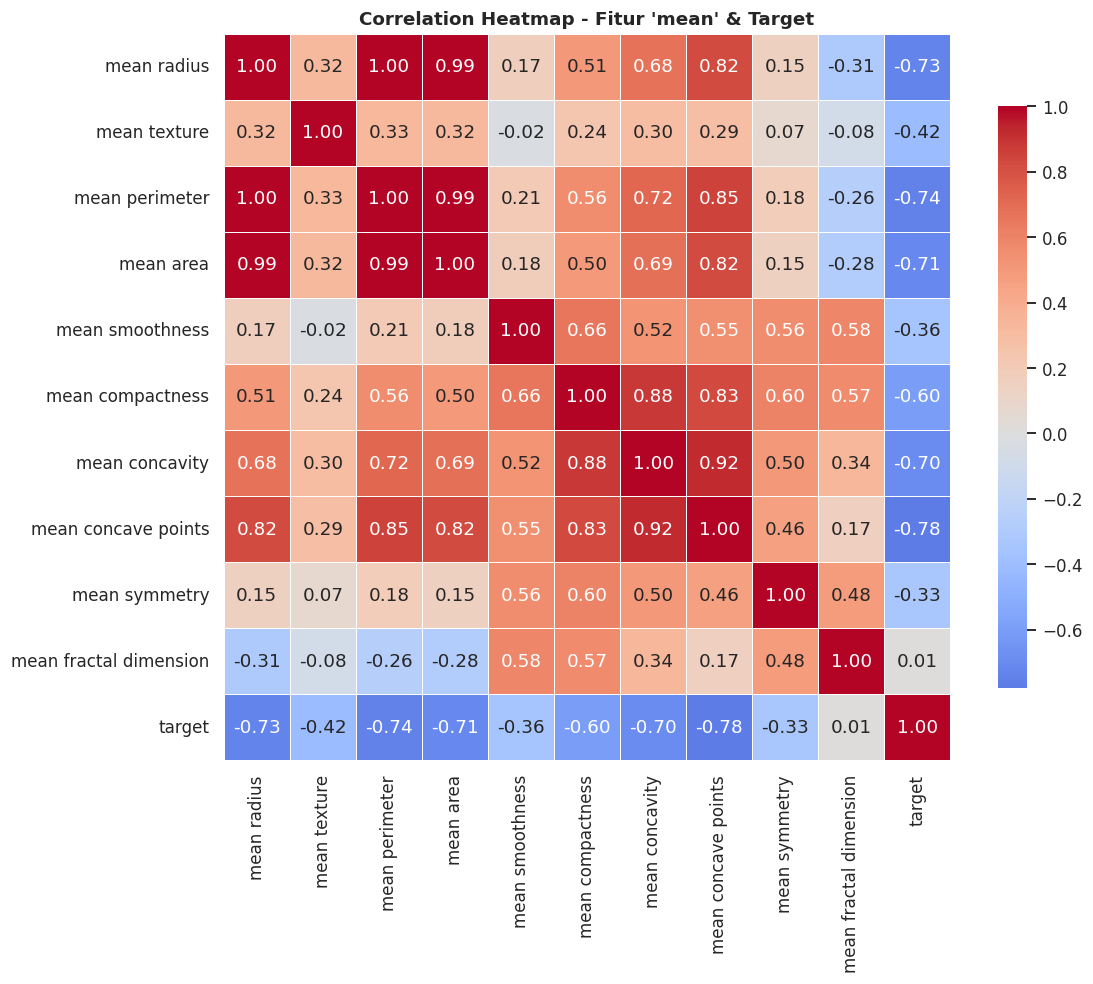

In [ ]:
plt.figure(figsize=(11, 9))
corr = df[mean_cols + ["target"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap - Fitur 'mean' & Target", fontweight="bold")
plt.tight_layout()
plt.show()


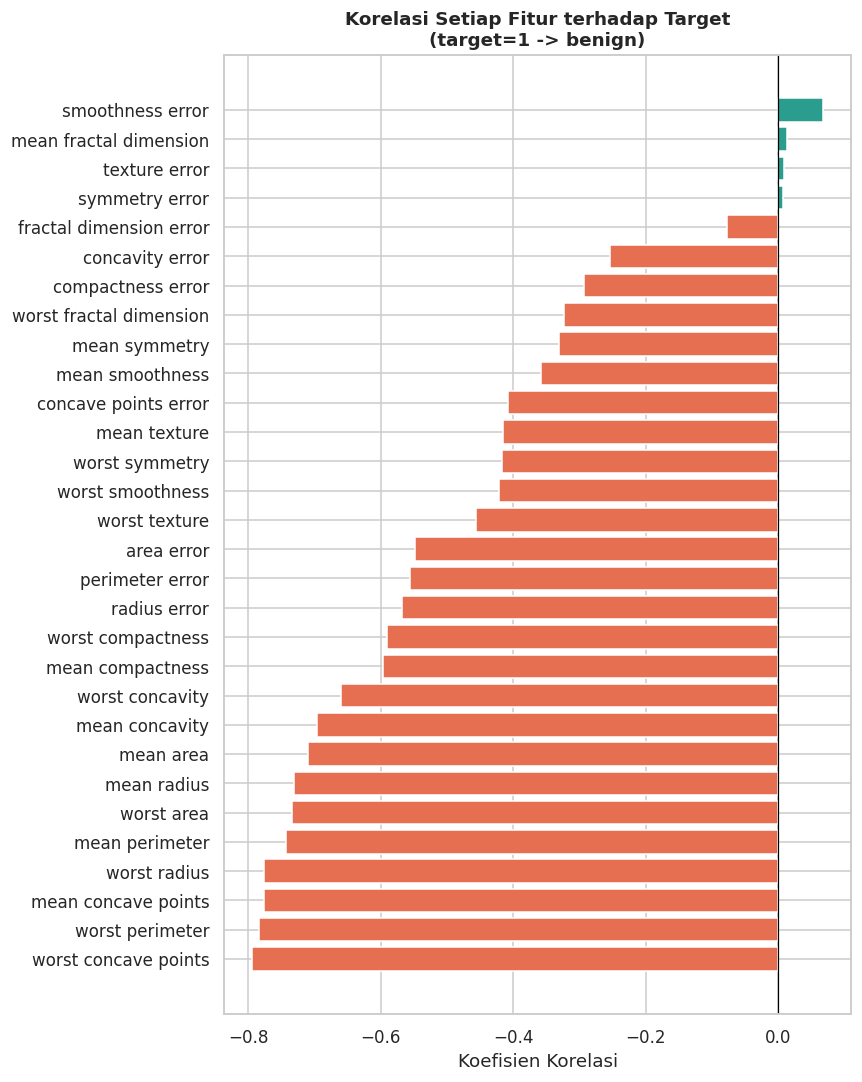

In [ ]:
target_corr = df.drop(columns=["diagnosis"]).corr()["target"].drop("target").sort_values()

plt.figure(figsize=(8, 10))
colors = ["#e76f51" if v < 0 else "#2a9d8f" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Korelasi Setiap Fitur terhadap Target\n(target=1 -> benign)", fontweight="bold")
plt.xlabel("Koefisien Korelasi")
plt.tight_layout()
plt.show()


### Analisis heatmap dan korelasi target

Karena `target = 0` berarti malignant dan `target = 1` benign, korelasi negatif berarti **nilai fitur yang lebih tinggi berkaitan dengan malignant**. Nilai yang paling kuat adalah `worst concave points` (**r ≈ −0,794**), `worst perimeter` (**−0,783**), `mean concave points` (**−0,777**), dan `worst radius` (**−0,776**). Pada heatmap fitur `mean`, radius, perimeter, dan area membentuk blok korelasi positif kuat. Korelasi Pearson menangkap kecenderungan linear; nilainya tidak menunjukkan sebab akibat atau kemampuan generalisasi model.

### 8.2 Clustermap
*Hierarchical clustering* diterapkan pada matriks korelasi untuk mengelompokkan fitur yang membawa informasi serupa. Cluster yang terbentuk menunjukkan kelompok fitur redundan.

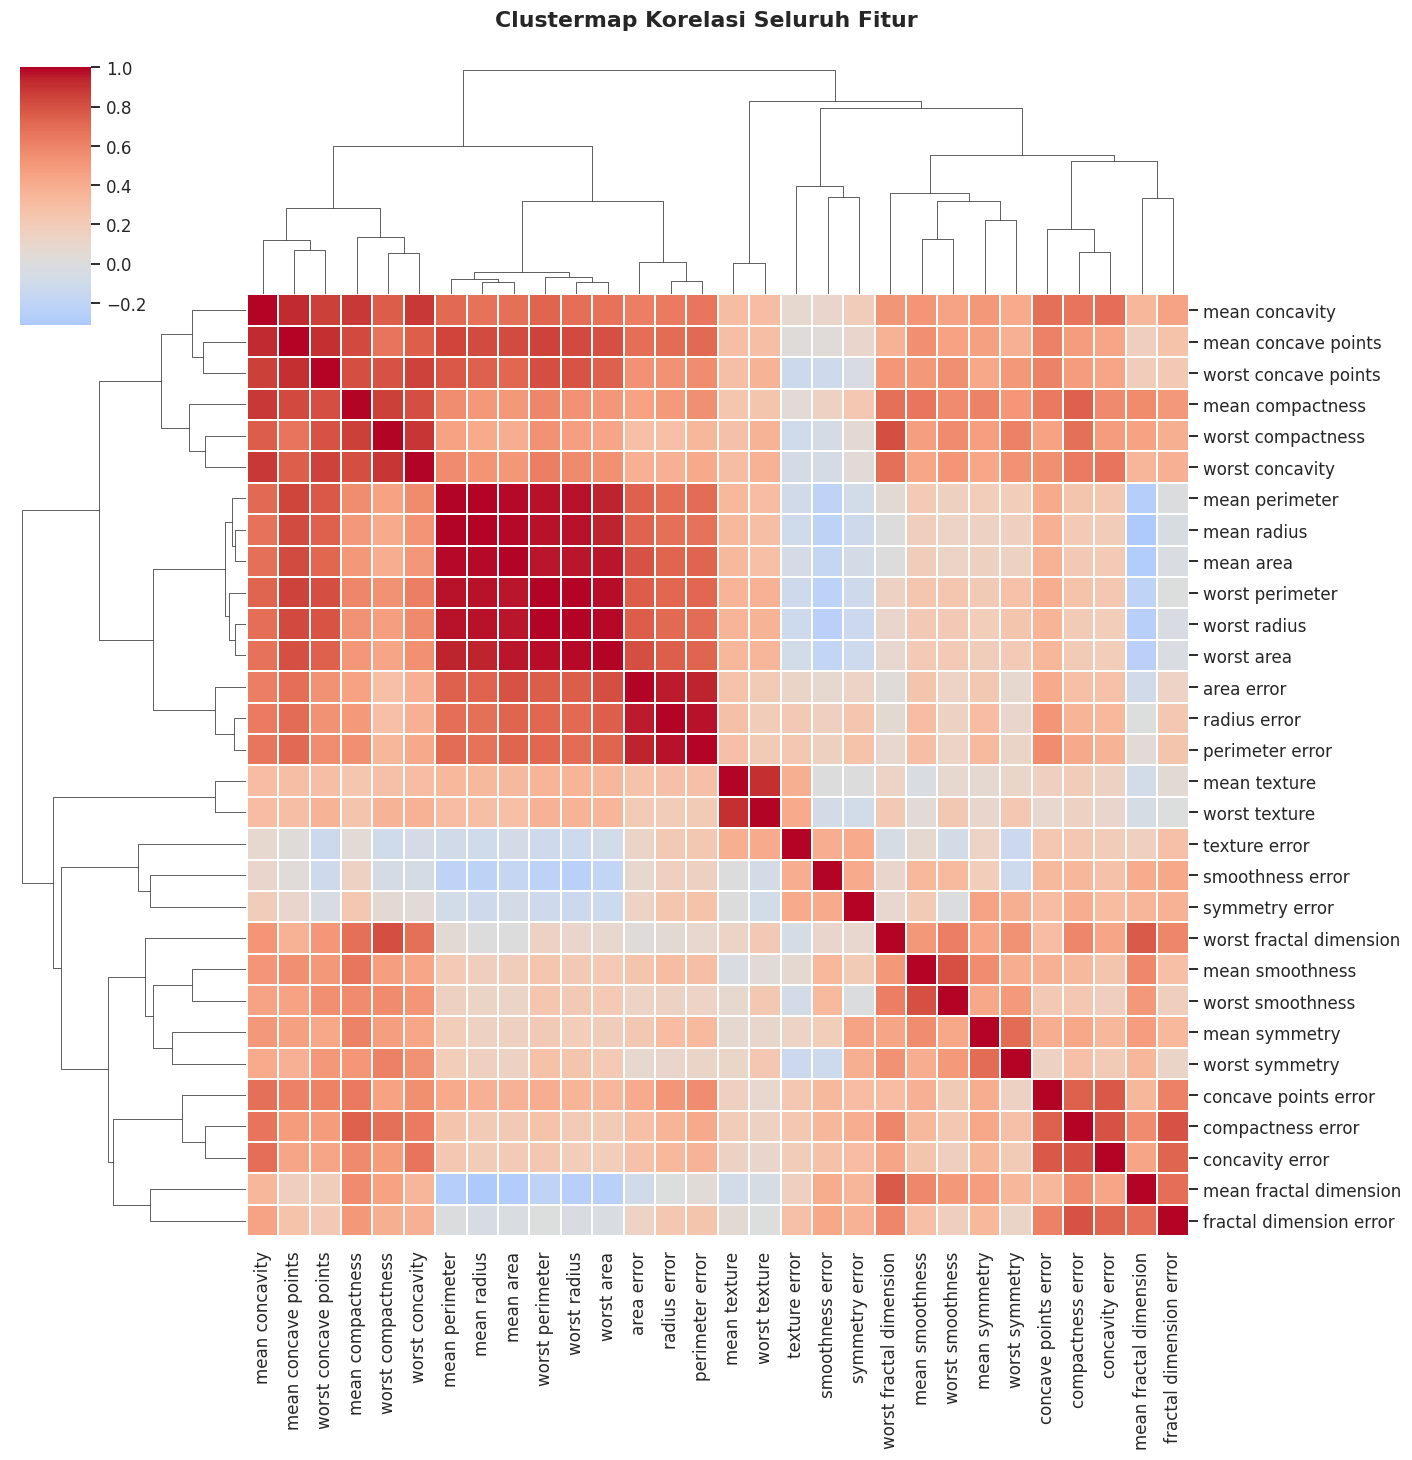

In [ ]:
# =========================================
# VISUALISASI: Hierarchical Clustermap (seluruh 30 fitur)
# =========================================
corr_all = df[list(data.feature_names)].corr()
g = sns.clustermap(corr_all, cmap="coolwarm", center=0, figsize=(13, 13),
                    linewidths=0.3, cbar_kws={"shrink": 0.6})
g.fig.suptitle("Clustermap Korelasi Seluruh Fitur", fontweight="bold", y=1.02)
plt.show()


**Pembacaan clustermap:** Blok warna hangat mengelompokkan fitur ukuran pada kelompok `mean`, `error`, dan `worst`. Cabang yang berdekatan menandakan pola korelasi yang mirip, sehingga banyak plot ukuran menggambarkan sinyal yang berulang. Klaster pada matriks korelasi tidak dapat ditafsirkan sebagai kelompok pasien atau kategori klinis.

### 8.3 Pasangan Fitur dengan Korelasi Sangat Tinggi (|r| > 0,9)
Pasangan fitur dengan korelasi absolut di atas 0,9 diidentifikasi sebagai indikasi redundansi informasi.

In [ ]:
corr_matrix = corr_all.abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .query("abs_corr > 0.9")
    .sort_values("abs_corr", ascending=False)
)
print(f"Jumlah pasangan fitur dengan |korelasi| > 0.9 : {len(high_corr_pairs)}")
high_corr_pairs.head(15)


Jumlah pasangan fitur dengan |korelasi| > 0.9 : 21


,feature_1,feature_2,abs_corr
1,mean radius,mean perimeter,0.997855
391,worst radius,worst perimeter,0.993708
2,mean radius,mean area,0.987357
57,mean perimeter,mean area,0.986507
392,worst radius,worst area,0.984015
407,worst perimeter,worst area,0.977578
246,radius error,perimeter error,0.972794
76,mean perimeter,worst perimeter,0.970387
19,mean radius,worst radius,0.969539
74,mean perimeter,worst radius,0.969476


**Analisis redundansi:** Terdapat **21 pasangan fitur** dengan |r| > 0,9. `mean radius` dan `mean perimeter` hampir identik secara korelasi (**r ≈ 0,998**), begitu pula `worst radius` dan `worst perimeter` (**≈ 0,994**). Dalam model linear, memasukkan beberapa pengukuran ukuran yang sangat mirip dapat membuat koefisien individual tidak stabil, walaupun prediksi keseluruhan tetap dapat berguna.

### 8.4 Variance Inflation Factor (VIF)
VIF dihitung untuk kelompok fitur `mean` guna mengkuantifikasi multikolinearitas. Nilai VIF di atas 10 umumnya dianggap mengindikasikan multikolinearitas serius. Perhitungan dilakukan secara manual melalui regresi linear tiap fitur terhadap fitur lainnya, dengan rumus VIF = 1 / (1 − R²).

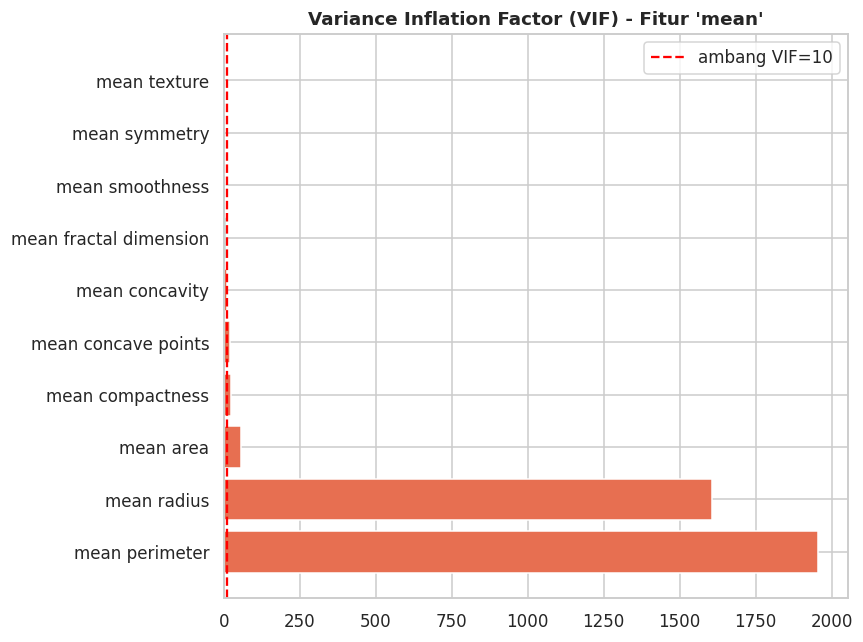

,feature,VIF
2,mean perimeter,1956.135364
0,mean radius,1606.805835
3,mean area,56.283984
5,mean compactness,22.619498
7,mean concave points,21.711976
6,mean concavity,11.715217
9,mean fractal dimension,6.472842
4,mean smoothness,2.957080
8,mean symmetry,1.778451
1,mean texture,1.186978


In [ ]:
# =========================================
# Hitung VIF secara manual (tanpa statsmodels) via regresi linear
# VIF_i = 1 / (1 - R2_i), R2_i dari regresi fitur i terhadap fitur lain
# =========================================
X_vif = df[mean_cols].values
vif_data = []
for i, col in enumerate(mean_cols):
    y_i = X_vif[:, i]
    X_others = np.delete(X_vif, i, axis=1)
    r2 = LinearRegression().fit(X_others, y_i).score(X_others, y_i)
    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_data.append({"feature": col, "VIF": vif})

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

plt.figure(figsize=(8, 6))
colors = np.where(vif_df["VIF"] > 10, "#e76f51", "#2a9d8f")
plt.barh(vif_df["feature"], vif_df["VIF"], color=colors)
plt.axvline(10, color="red", linestyle="--", label="ambang VIF=10")
plt.title("Variance Inflation Factor (VIF) - Fitur 'mean'", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

vif_df


### Analisis korelasi dan VIF

Grafik VIF memperjelas redundansi antar 10 fitur `mean`: `mean perimeter` **≈ 1.956**, `mean radius` **≈ 1.607**, dan `mean area` **≈ 56**, sedangkan `mean texture` **≈ 1,19**. VIF tinggi berarti fitur tersebut dapat diperkirakan dari fitur lain dalam kelompok ini. Hasil itu terutama menyulitkan **interpretasi koefisien** model linear; tidak berarti ketiga fitur wajib dihapus. Bandingkan regularisasi, pemilihan perwakilan fitur, atau PCA menggunakan validasi yang sama. Importance pada model pohon pun dapat terbagi di antara fitur yang saling berkorelasi.

## 9. Hubungan Multivariat
*Pairplot* dan *jointplot* digunakan pada fitur-fitur dengan korelasi tertinggi terhadap target untuk melihat apakah kombinasi dua atau lebih fitur mampu memisahkan kedua kelas secara visual.

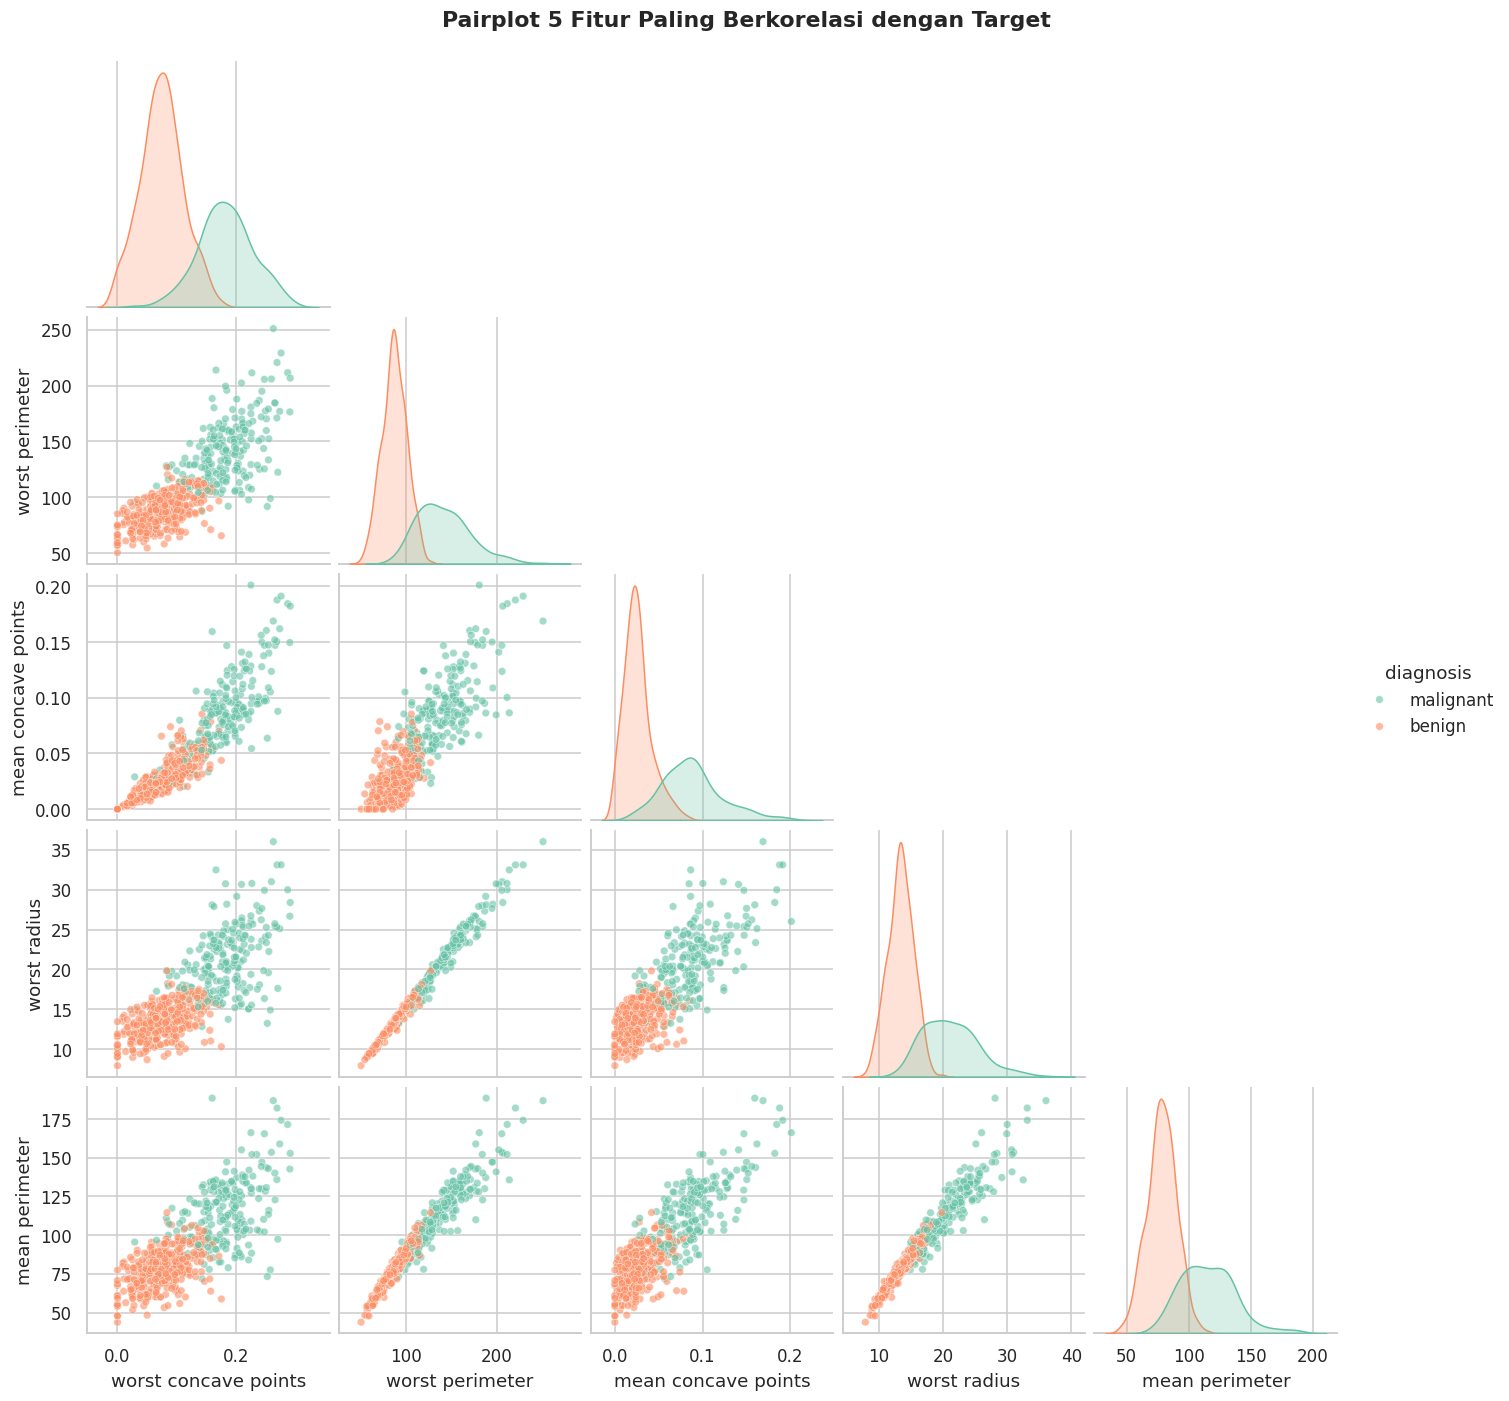

In [ ]:
top5 = target_corr.abs().sort_values(ascending=False).head(5).index.tolist()

sns.pairplot(df, vars=top5, hue="diagnosis", diag_kind="kde", corner=True,
             plot_kws={"alpha": 0.6, "s": 25})
plt.suptitle("Pairplot 5 Fitur Paling Berkorelasi dengan Target", y=1.02, fontweight="bold")
plt.show()


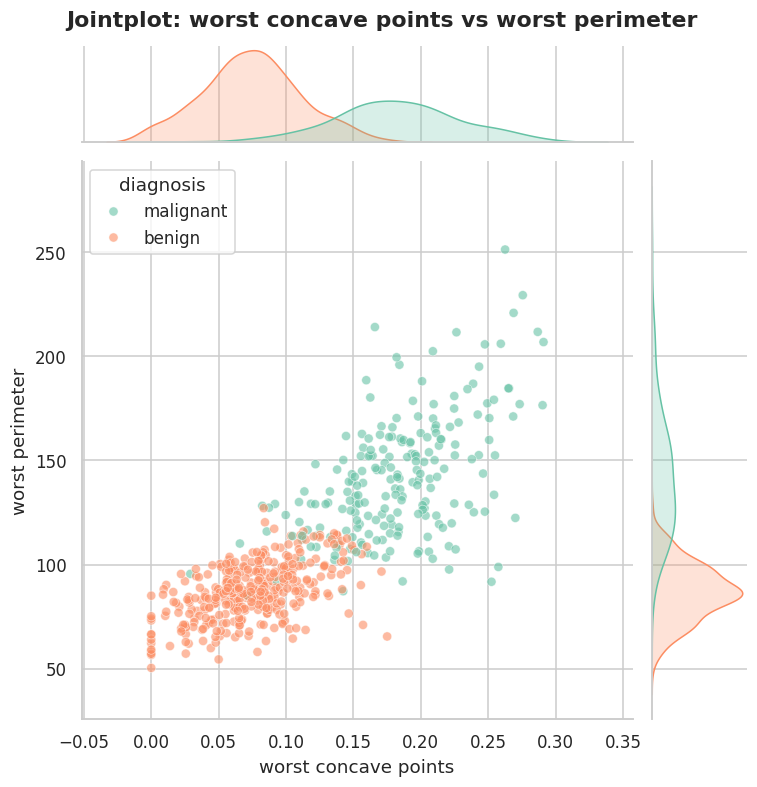

In [ ]:
# =========================================
# VISUALISASI: Jointplot 2 fitur paling berkorelasi
# =========================================
sns.jointplot(data=df, x=top5[0], y=top5[1], hue="diagnosis", height=7, alpha=0.6)
plt.suptitle(f"Jointplot: {top5[0]} vs {top5[1]}", y=1.02, fontweight="bold")
plt.show()


### Analisis pairplot dan jointplot

Plot diagonal menunjukkan distribusi per kelas, sedangkan panel pasangan menunjukkan hubungan antarf fitur. Pasangan `worst concave points` dan `worst perimeter` membentuk dua konsentrasi titik yang cenderung berbeda, **tetapi masih ada wilayah peralihan**. Banyak pasangan ukuran membentuk garis rapat karena saling berkorelasi, bukan karena masing-masing memberikan bukti independen. Lima fitur di plot dipilih dari korelasi pada seluruh dataset; visualisasi ini eksploratif dan tidak membuktikan bahwa model sudah mampu mengklasifikasi sampel baru.

## 10. Deteksi Outlier
Outlier dianalisis secara visual dan kuantitatif. Pada data medis, outlier tidak otomatis dianggap sebagai kesalahan karena dapat mencerminkan kasus klinis yang memang ekstrem.

### 10.1 Pendekatan Visual
Boxplot pada data yang telah distandarisasi memungkinkan perbandingan sebaran antar fitur dalam satu skala.

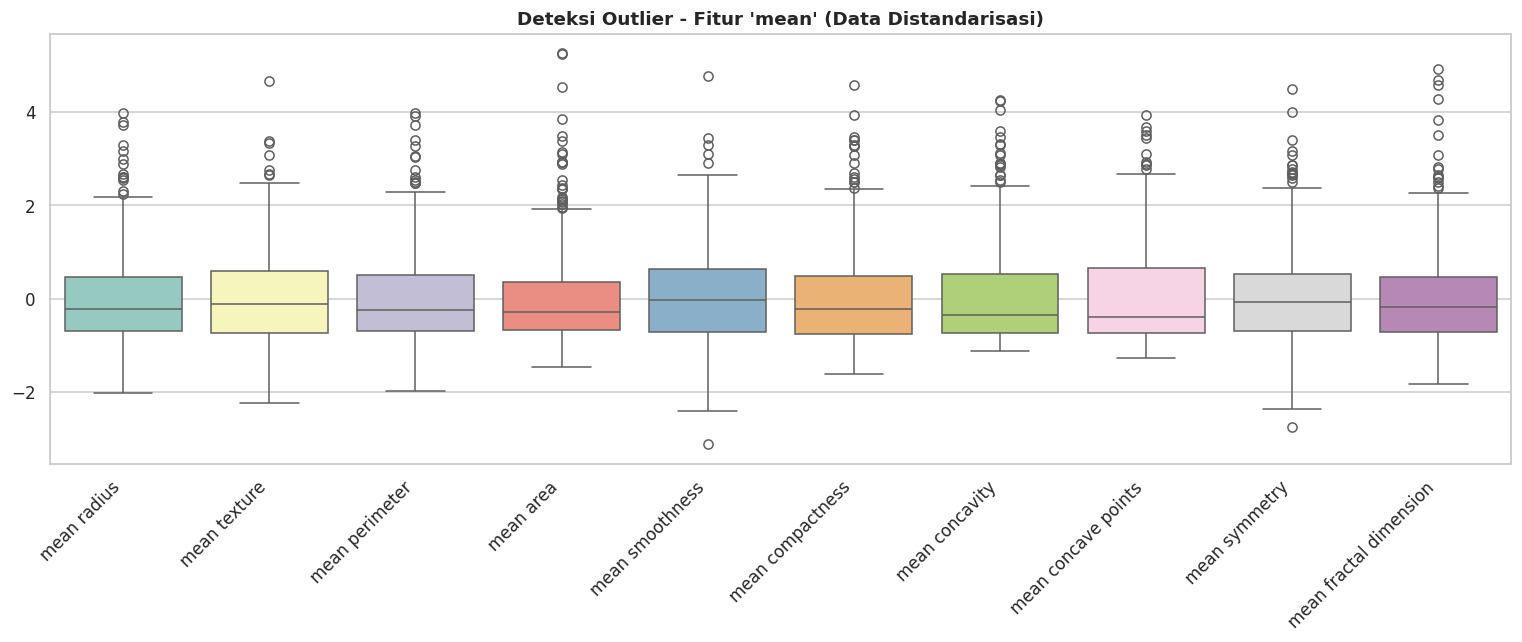

In [ ]:
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[mean_cols]), columns=mean_cols)

plt.figure(figsize=(14, 6))
sns.boxplot(data=scaled, palette="Set3")
plt.xticks(rotation=45, ha="right")
plt.title("Deteksi Outlier - Fitur 'mean' (Data Distandarisasi)", fontweight="bold")
plt.tight_layout()
plt.show()


### 10.2 Kuantifikasi dengan Metode IQR
Sampel dikategorikan sebagai outlier jika berada di luar rentang Q1 − 1,5×IQR hingga Q3 + 1,5×IQR.

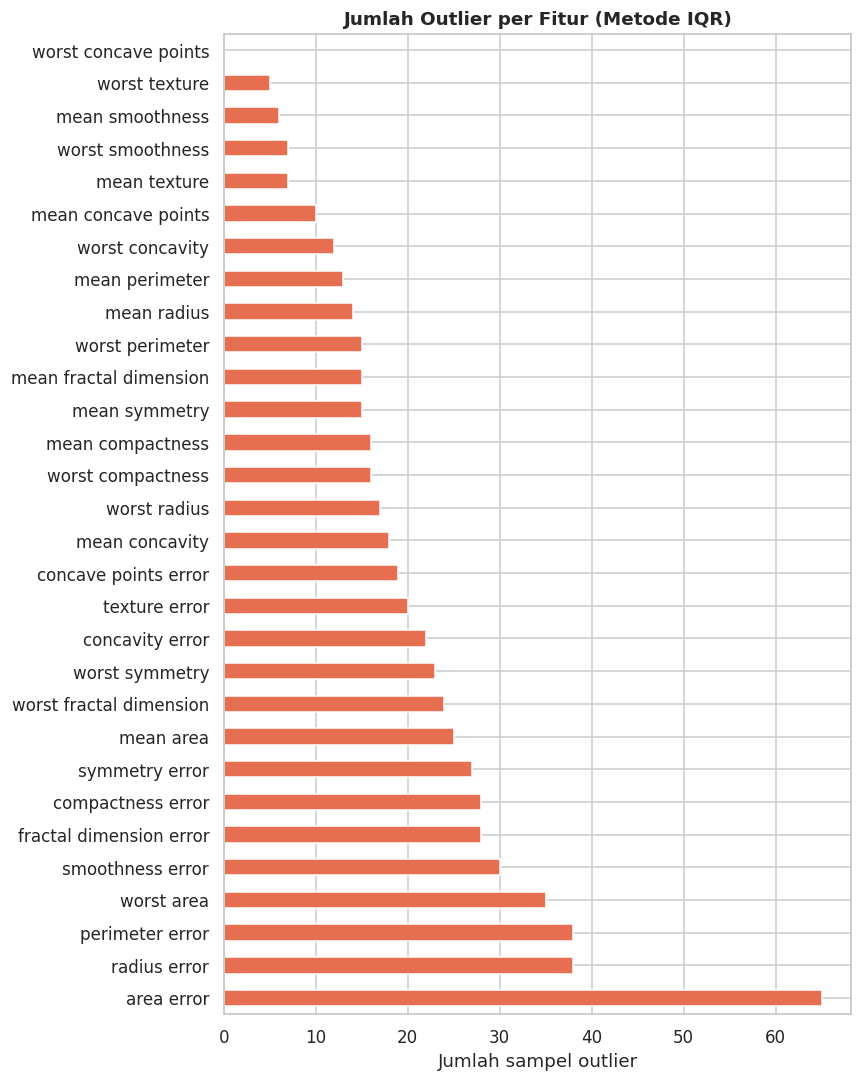

Total fitur dengan outlier > 0: 29 dari 30


In [ ]:
# =========================================
# Hitung jumlah outlier per fitur dengan metode IQR
# =========================================
outlier_counts = {}
for col in data.feature_names:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_df = pd.Series(outlier_counts).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
outlier_df.plot.barh(color="#e76f51")
plt.title("Jumlah Outlier per Fitur (Metode IQR)", fontweight="bold")
plt.xlabel("Jumlah sampel outlier")
plt.tight_layout()
plt.show()

print(f"Total fitur dengan outlier > 0: {(outlier_df > 0).sum()} dari {len(outlier_df)}")


### Analisis outlier

Dengan aturan **1,5 × IQR**, **29 dari 30 fitur** memiliki setidaknya satu nilai yang ditandai ekstrem. Ini adalah banyaknya *fitur*, bukan 29 sampel. Batang tertinggi pada grafik adalah `area error` (**65 sampel**), disusul `radius error` dan `perimeter error` (**masing-masing 38**), lalu `worst area` (**35**); satu sampel dapat dihitung pada beberapa fitur. `worst concave points` tidak mempunyai nilai di luar batas IQR.

Banyaknya penanda pada fitur error konsisten dengan ekor kanan yang terlihat pada grafik skewness. Metode IQR tidak membuktikan apakah suatu nilai salah ukur atau benar-benar kasus ekstrem. Karena itu, periksa sampel dan sebarannya per kelas sebelum menghapus atau mengubah nilai. Standardisasi pada boxplot di sini hanya untuk EDA; jika dipakai dalam model, scaler harus di-*fit* pada data latih saja.

## 11. Reduksi Dimensi
Reduksi dimensi digunakan untuk dua tujuan: mengukur tingkat redundansi informasi antar fitur, dan memvisualisasikan pemisahan kelas pada ruang berdimensi rendah. Dua metode dibandingkan: **PCA** (linear) dan **t-SNE** (non-linear). Kedua metode hanya digunakan untuk eksplorasi visual pada tahap ini.

### 11.1 Scree Plot
Scree plot menunjukkan proporsi varians yang dijelaskan oleh tiap komponen utama, sehingga dapat ditentukan jumlah komponen yang cukup untuk merepresentasikan data.

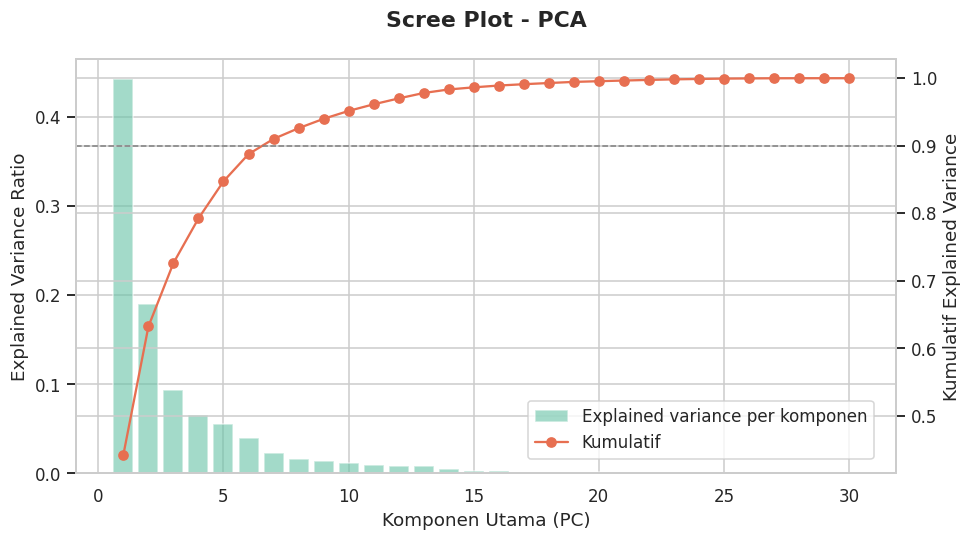

Jumlah komponen untuk menjelaskan >=90% varians: 7 dari 30 fitur asli


In [ ]:
X_scaled = StandardScaler().fit_transform(df[data.feature_names])
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(range(1, len(cum_var) + 1), pca_full.explained_variance_ratio_, alpha=0.6, label="Explained variance per komponen")
ax1.set_xlabel("Komponen Utama (PC)")
ax1.set_ylabel("Explained Variance Ratio")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var) + 1), cum_var, color="#e76f51", marker="o", label="Kumulatif")
ax2.axhline(0.9, color="grey", linestyle="--", linewidth=1)
ax2.set_ylabel("Kumulatif Explained Variance")

fig.suptitle("Scree Plot - PCA", fontweight="bold")
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.show()

n_90 = np.argmax(cum_var >= 0.9) + 1
print(f"Jumlah komponen untuk menjelaskan >=90% varians: {n_90} dari {X_scaled.shape[1]} fitur asli")


### 11.2 Visualisasi PCA 2D dan t-SNE 2D
Seluruh fitur distandarisasi terlebih dahulu, kemudian diproyeksikan ke dua dimensi menggunakan PCA dan t-SNE.

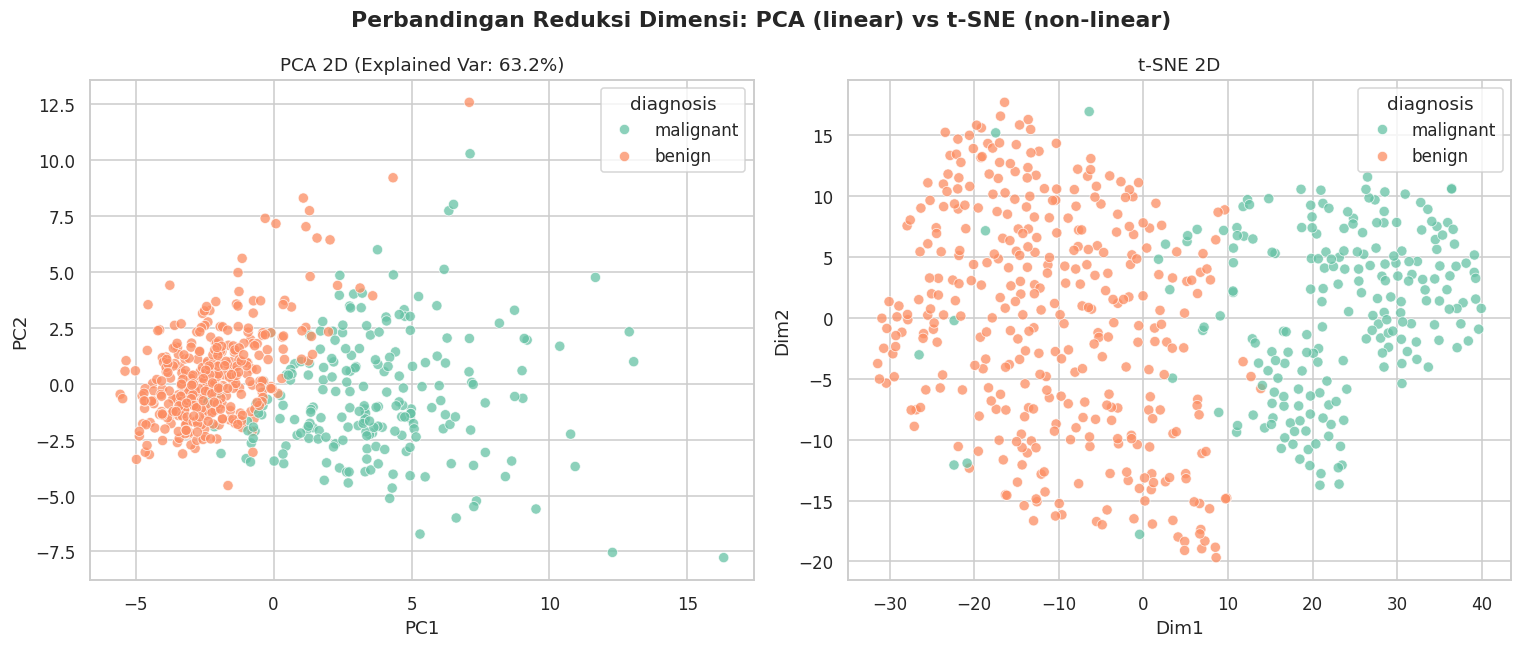

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["diagnosis"] = df["diagnosis"].values

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
tsne_result = tsne.fit_transform(X_scaled)
tsne_df = pd.DataFrame(tsne_result, columns=["Dim1", "Dim2"])
tsne_df["diagnosis"] = df["diagnosis"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="diagnosis", alpha=0.75, s=45, ax=axes[0])
axes[0].set_title(f"PCA 2D (Explained Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)")

sns.scatterplot(data=tsne_df, x="Dim1", y="Dim2", hue="diagnosis", alpha=0.75, s=45, ax=axes[1])
axes[1].set_title("t-SNE 2D")

plt.suptitle("Perbandingan Reduksi Dimensi: PCA (linear) vs t-SNE (non-linear)", fontweight="bold")
plt.tight_layout()
plt.show()


### Analisis PCA dan t-SNE

Setelah 30 fitur distandarisasi, PC1 menjelaskan **44,27%** varians dan PC2 **18,97%**; plot PCA 2D menampilkan **63,24%** varians total. **Tujuh komponen** diperlukan untuk mencapai **91,01%**. Ini selaras dengan banyaknya pengukuran yang berkorelasi, tetapi persentase varians yang terjaga tidak sama dengan persentase informasi diagnosis yang terjaga.

Pada scatter PCA, dua kelas punya kecenderungan posisi berbeda namun **tumpang tindih jelas**. Plot t-SNE tampak membentuk kelompok lokal yang lebih terpisah, dengan beberapa titik tetap bercampur. Tampilan tersebut bergantung pada parameter dan seed; jarak antarkelompok t-SNE tidak dapat dibandingkan langsung dengan PCA, dan tidak dapat digunakan untuk menyimpulkan akurasi klasifikasi. Saat PCA digunakan pada model, standardisasi dan PCA harus di-*fit* ulang hanya di dalam data latih tiap fold.

## 12. Estimasi Awal Feature Importance
Sebelum membangun model, relevansi tiap fitur diestimasi menggunakan dua pendekatan berbeda:
- **ANOVA F-score**: mengukur perbedaan rata-rata antar kelas (menangkap hubungan linear).
- **Mutual Information**: mengukur ketergantungan antara fitur dan target, termasuk hubungan non-linear.

Konsistensi hasil dari kedua metode meningkatkan keyakinan atas ranking fitur.

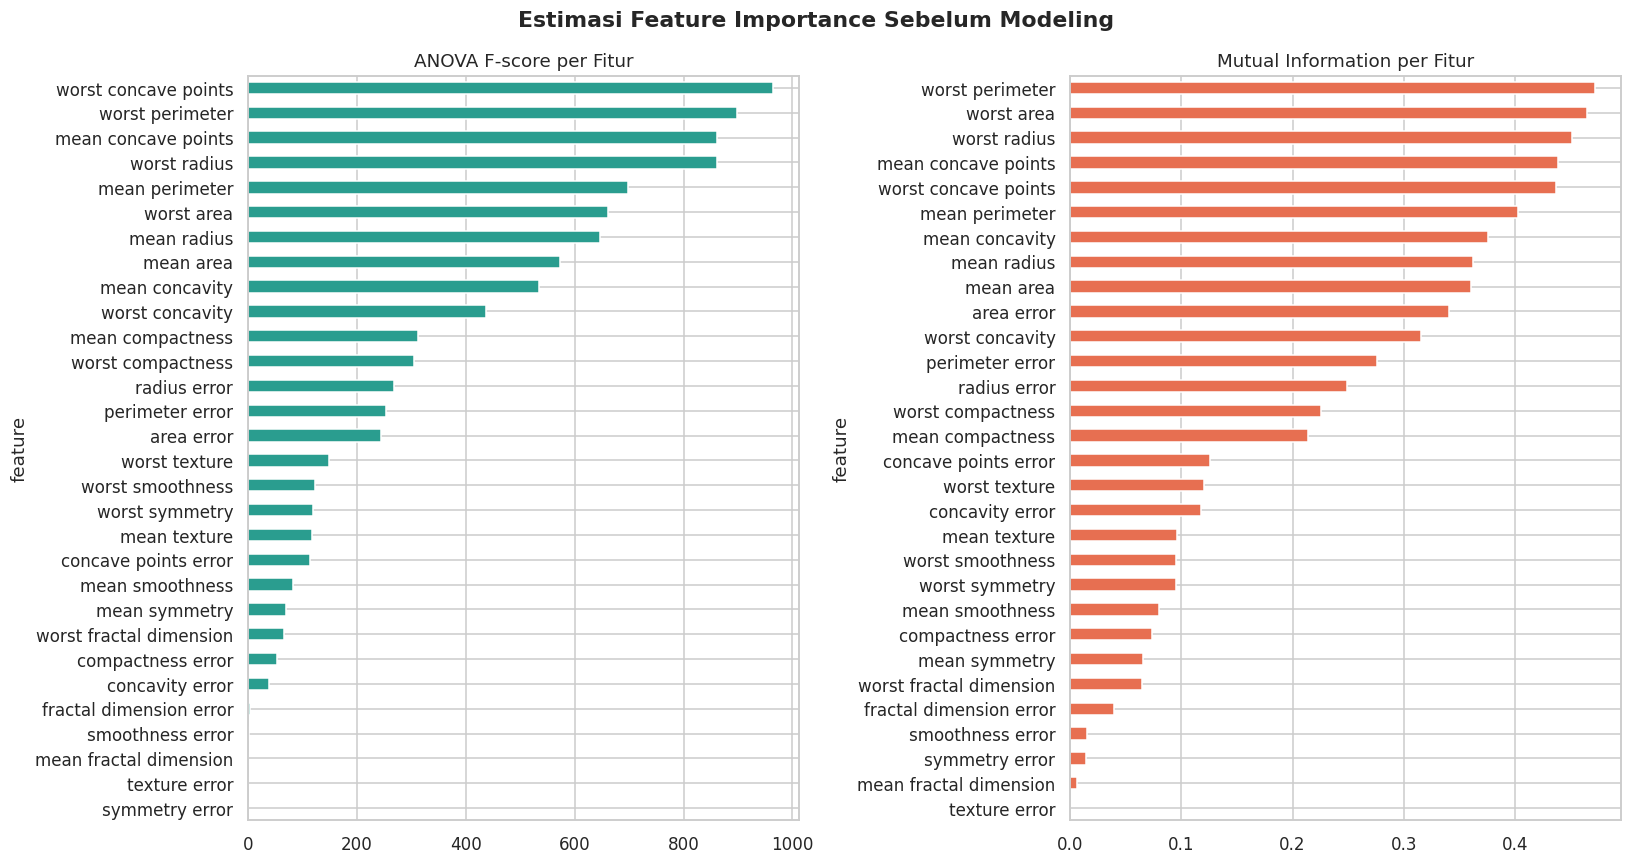

,feature,f_score,mutual_info
22,worst perimeter,897.944219,0.471842
23,worst area,661.600206,0.464313
20,worst radius,860.781707,0.451230
7,mean concave points,861.676020,0.438806
27,worst concave points,964.385393,0.436255
2,mean perimeter,697.235272,0.402361
6,mean concavity,533.793126,0.375447
0,mean radius,646.981021,0.362276
3,mean area,573.060747,0.360023
13,area error,243.651586,0.340759


In [ ]:
X = df[data.feature_names]
y = df["target"]

f_scores, _ = f_classif(X, y)
mi_scores = mutual_info_classif(X, y, random_state=42)

importance_df = pd.DataFrame({
    "feature": data.feature_names,
    "f_score": f_scores,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
importance_df.sort_values("f_score").plot.barh(x="feature", y="f_score", ax=axes[0], legend=False, color="#2a9d8f")
axes[0].set_title("ANOVA F-score per Fitur")

importance_df.sort_values("mutual_info").plot.barh(x="feature", y="mutual_info", ax=axes[1], legend=False, color="#e76f51")
axes[1].set_title("Mutual Information per Fitur")

plt.suptitle("Estimasi Feature Importance Sebelum Modeling", fontweight="bold")
plt.tight_layout()
plt.show()

importance_df.head(10)


### Analisis pemeringkatan fitur

ANOVA F-score menempatkan `worst concave points` paling tinggi (**≈ 964,4**), sedangkan Mutual Information menempatkan `worst perimeter` paling tinggi (**≈ 0,472**). `worst area`, `worst radius`, dan `mean concave points` juga berulang di peringkat atas. Grafik ini mendukung temuan ukuran dan kontur pada analisis distribusi serta korelasi. Namun, kedua metode memberi **skor univariat** dan berskala berbeda; peringkat tinggi tidak berarti kontribusi tambahan yang besar setelah fitur berkorelasi lain dimasukkan. Seleksi fitur untuk evaluasi model perlu dilakukan di dalam fold pelatihan.

## 13. Kesimpulan & Rencana Tahap Berikutnya

### Jawaban Utama dari EDA

1. **Struktur data:** 569 sampel, 30 fitur numerik, tanpa nilai kosong atau baris duplikat. `target` dan `diagnosis` adalah dua representasi label yang sama.
2. **Komposisi kelas:** benign **357 (62,7%)**, malignant **212 (37,3%)**. Akurasi mayoritas 62,7% menjadi pembanding awal yang perlu dilampaui secara bermakna.
3. **Perbedaan sel:** fitur ukuran dan kontur cenderung lebih tinggi pada malignant. Median `mean area` **932,0 vs 458,4** dan `mean concave points` **0,0863 vs 0,0234** (malignant vs benign), tetapi distribusinya masih tumpang tindih.
4. **Uji statistik:** 27/30 fitur memiliki p < 0,05 pada Mann–Whitney U dan tetap lolos FDR 5%. Tiga fitur yang tidak lolos belum dapat dieliminasi hanya berdasarkan uji tunggal.
5. **Redundansi:** 21 pasangan memiliki |r| > 0,9; VIF `mean perimeter` ≈ **1.956**. Interpretasi koefisien linear memerlukan perhatian khusus.
6. **Sebaran dan outlier:** 22 fitur menceng ke kanan (skewness > 1); `area error` memiliki **65** nilai di luar batas IQR. Status kesalahan pengukuran belum dapat diputuskan dari aturan IQR.
7. **Dimensi:** 7 komponen PCA menjelaskan **91,01%** varians; PCA 2D hanya **63,24%**. Plot dua dimensi menunjukkan pola kelas sekaligus area tumpang tindih.
8. **Kandidat fitur:** `worst concave points`, `worst perimeter`, `worst radius`, dan `mean concave points` menonjol dalam analisis univariat, tetapi kontribusi gabungannya dan performa pada data baru belum diuji.

### Tahap Berikutnya

| Tahap | Rencana |
|---|---|
| Pemisahan data | Gunakan *stratified train/test split*; tahan test set hingga keputusan eksperimen selesai. |
| Pipeline | Fit standardisasi, transformasi jika dipilih, seleksi fitur/PCA, dan model hanya pada fold pelatihan. |
| Baseline | Bandingkan Logistic Regression terregularisasi, SVM, dan model pohon pada skema validasi yang sama. |
| Evaluasi | Laporkan confusion matrix, recall malignant, precision, F1, ROC-AUC, serta PR-AUC jika relevan; bandingkan dengan baseline mayoritas. |

**Batasan:** Ini analisis eksploratif pada dataset sekunder dari citra sampel sel. Perbedaan distribusi tidak membuktikan hubungan sebab akibat, performa klinis, atau generalisasi ke fasilitas dan populasi lain. Ambang keputusan medis tidak ditentukan dalam notebook ini.